# Curve trades with macroeconomic signals

## Get packages and JPMaQS data

### Get packages

In [1]:
# Python packages, modules and functions

import pandas as pd
import os
import numpy as np

import macrosynergy.management as msm
import macrosynergy.panel as msp
import macrosynergy.visuals as msv
import macrosynergy.signal as mss
import macrosynergy.pnl as msn
from macrosynergy.download import JPMaQSDownload

from datetime import timedelta, date, datetime
from itertools import combinations
import warnings

warnings.simplefilter("ignore")

### Download JPMaQS data

In [2]:
# Parameters for data download

DQ_CLIENT_ID = os.getenv("DQ_CLIENT_ID")
DQ_CLIENT_SECRET = os.getenv("DQ_CLIENT_SECRET")
START_DATE = "2000-01-01"
END_DATE: str = (pd.Timestamp.today() - pd.offsets.BDay(1)).strftime('%Y-%m-%d')

In [3]:
# Cross-sectional lists

cids_dm = sorted(["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK", "USD"])
cids_g2 = ["EUR", "USD"]
cids_xg2 = sorted(list(set(cids_dm) - set(cids_g2)))

cids_ez = ["DEM", "ESP", "FRF", "ITL"]  # for EUR fiscal aggregates

cids = sorted(cids_dm + cids_ez)


In [4]:
# Categories

# Economic categories

labor = [
    "EMPL_NSA_P1M1ML12_3MMA",
    "EMPL_NSA_P1Q1QL4",
    "WFORCE_NSA_P1Y1YL1_5YMM",
    "WFORCE_NSA_P1Q1QL4_20QMM",
    "UNEMPLRATE_NSA_3MMA_D1M1ML12",
    "UNEMPLRATE_NSA_D1Q1QL4",
    "UNEMPLRATE_SA_D3M3ML3",
    "UNEMPLRATE_SA_3MMA",
    "UNEMPLRATE_SA_3MMAv5YMM",
    "UNEMPLRATE_SA_3MMAv10YMM",
]
growth = [
    "INTRGDP_NSA_P1M1ML12_3MMA",
    "IMPORTS_SA_P1M1ML12_3MMA",
    "NRSALES_SA_P1M1ML12_3MMA",
    "NRSALES_SA_P1Q1QL4",
    "RRSALES_SA_P1M1ML12_3MMA",
    "RRSALES_SA_P1Q1QL4",
    "RPCONS_SA_P1M1ML12_3MMA",
    "RPCONS_SA_P1Q1QL4",
    "RGDPTECH_SA_P1M1ML12_3MMA",
    "RGDP_SA_P1Q1QL4_20QMM",
]
inflation = [
    "CPIH_SA_P1M1ML12",
    "CPIH_SJA_P6M6ML6AR",
    "CPIC_SA_P1M1ML12",
    "CPIC_SJA_P6M6ML6AR",
    "INFTEFF_NSA",
    "INFE2Y_JA",
    "INFE5Y_JA",
    "HPI_SA_P1Q1QL4",
    "HPI_SA_P1M1ML12_3MMA",
]
monliq = [
    "PCREDITBN_SJA_P1M1ML12",
    "INTLIQGDP_NSA_D1M1ML1",
    "INTLIQGDP_NSA_D1M1ML3",
    "INTLIQGDP_NSA_D1M1ML6",
]
fiscal = [
    "GGDGDPRATIOX10_NSA",
    "USDGDPWGT_SA_3YMA",
]
surveys = [
    "CCSCORE_SA",
    "CCSCORE_SA_3MMA",
    "CCSCORE_SA_D3M3ML3",
    "CCSCORE_SA_D1Q1QL1",
    "SBCSCORE_SA",
    "SBCSCORE_SA_3MMA",
    "SBCSCORE_SA_D3M3ML3",
    "SBCSCORE_SA_D1Q1QL1",
    "MBCSCORE_SA",
    "MBCSCORE_SA_3MMA",
    "MBCSCORE_SA_D3M3ML3",
    "MBCSCORE_SA_D1Q1QL1",
]

ecos = labor + inflation + growth + monliq + fiscal + surveys

# Market categories

rets = [
    "DU02YXR_NSA",
    "DU10YXR_NSA",
]
ylds = [
    "DU02YYLD_NSA",
    "DU10YYLD_NSA",
]

markets = rets + ylds

# All categories

xcats = ecos + markets

In [5]:
# Tickers for download

extras = ["USD_GB05YXR_NSA", "USD_EQXR_NSA"]
tickers = [cid + "_" + xcat for cid in cids for xcat in xcats] + extras

print(f"{len(tickers)} tickers to download.")

716 tickers to download.


In [6]:
# Download JPMaQS data

with JPMaQSDownload(client_id=DQ_CLIENT_ID, client_secret=DQ_CLIENT_SECRET) as dq:
    df = dq.download(
        tickers=tickers,
        start_date=START_DATE,
        end_date=END_DATE,
        suppress_warning=True,
        metrics=["value"],  
        report_time_taken=True,
        show_progress=True,
    )

Timestamp UTC:  2026-04-29 11:46:57
Connection successful!


Requesting data: 100%|██████████| 36/36 [00:09<00:00,  3.96it/s]


Time taken to download data: 	47.76 seconds.
Some expressions are missing from the downloaded data. Check logger output for complete list.
192 out of 716 expressions are missing. To download the catalogue of all available expressions and filter the unavailable expressions, set `get_catalogue=True` in the call to `JPMaQSDownload.download()`.


In [7]:
dfx = df.copy()
dfx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3511631 entries, 0 to 3511630
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   real_date  datetime64[ns]
 1   cid        object        
 2   xcat       object        
 3   value      float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 107.2+ MB


## Pre-processing, availability, and blacklisting

### Renamings

In [8]:
# Remove survey levels that are not quarterly frequency

for xcat in ["CCSCORE_SA", "SBCSCORE_SA", "MBCSCORE_SA"]:
    cids_with_3mma = dfx.loc[dfx["xcat"] == f"{xcat}_3MMA", "cid"].unique()
    dfx = dfx[
        ~(
            (dfx["xcat"] == xcat) &
            (dfx["cid"].isin(cids_with_3mma))
        )
    ].copy()

In [9]:
# Rename quarterly tickers to monthly equivalents

dict_repl = {
    "EMPL_NSA_P1Q1QL4": "EMPL_NSA_P1M1ML12_3MMA",
    "WFORCE_NSA_P1Q1QL4_20QMM": "WFORCE_NSA_P1Y1YL1_5YMM",
    "UNEMPLRATE_NSA_D1Q1QL4": "UNEMPLRATE_NSA_3MMA_D1M1ML12",
    "NRSALES_SA_P1Q1QL4": "NRSALES_SA_P1M1ML12_3MMA",
    "RRSALES_SA_P1Q1QL4": "RRSALES_SA_P1M1ML12_3MMA",
    "RPCONS_SA_P1Q1QL4": "RPCONS_SA_P1M1ML12_3MMA",
    "HPI_SA_P1Q1QL4": "HPI_SA_P1M1ML12_3MMA",
    "CCSCORE_SA": "CCSCORE_SA_3MMA",
    "SBCSCORE_SA": "SBCSCORE_SA_3MMA",
    "MBCSCORE_SA": "MBCSCORE_SA_3MMA",
    "CCSCORE_SA_D1Q1QL1": "CCSCORE_SA_D3M3ML3",
    "MBCSCORE_SA_D1Q1QL1": "MBCSCORE_SA_D3M3ML3",
    "SBCSCORE_SA_D1Q1QL1": "SBCSCORE_SA_D3M3ML3",
}

for key, value in dict_repl.items():
    dfx["xcat"] = dfx["xcat"].replace(key, value)

non_grata = list(dict_repl.keys())

### Synthetic euro area category

In [10]:
# Extrapolated debt-to-GDP ratio

dfa = msp.linear_composite(
    df=dfx,
    xcats="GGDGDPRATIOX10_NSA",
    cids=cids_ez,
    weights="USDGDPWGT_SA_3YMA",
    normalize_weights=True,
    new_cid="EUR",
)
dfx = msm.update_df(dfx, dfa)

### Availability checks

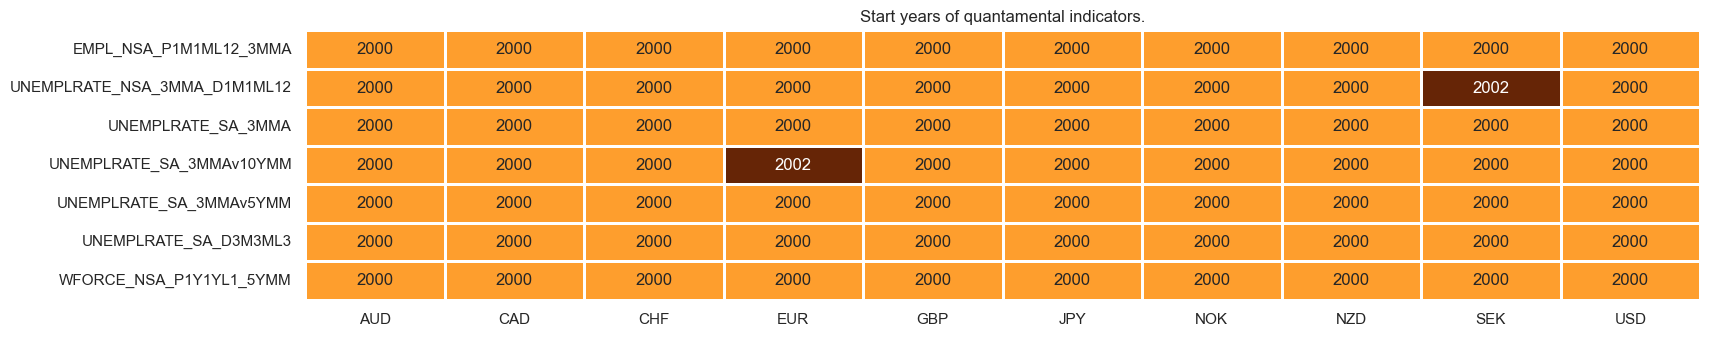

In [11]:
xcatx = sorted(list(set(labor) - set(non_grata)))
cidx = cids_dm

msm.check_availability(dfx, xcats=xcatx, cids=cidx, missing_recent=False)

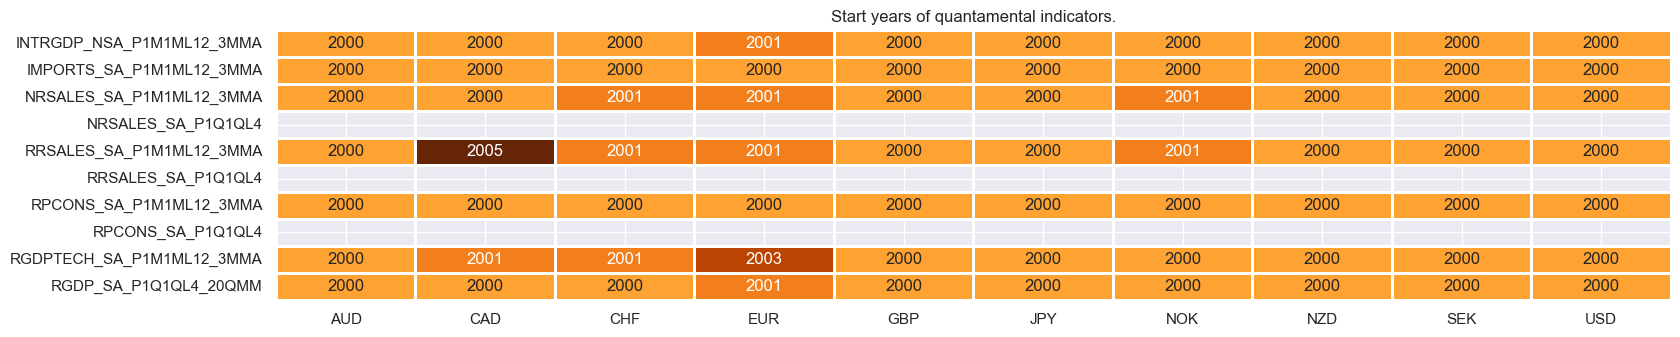

In [12]:
xcatx = growth # sorted(list(set(growth) - set(non_grata)))
cidx = cids_dm

msm.check_availability(dfx, xcats=xcatx, cids=cidx, missing_recent=False)

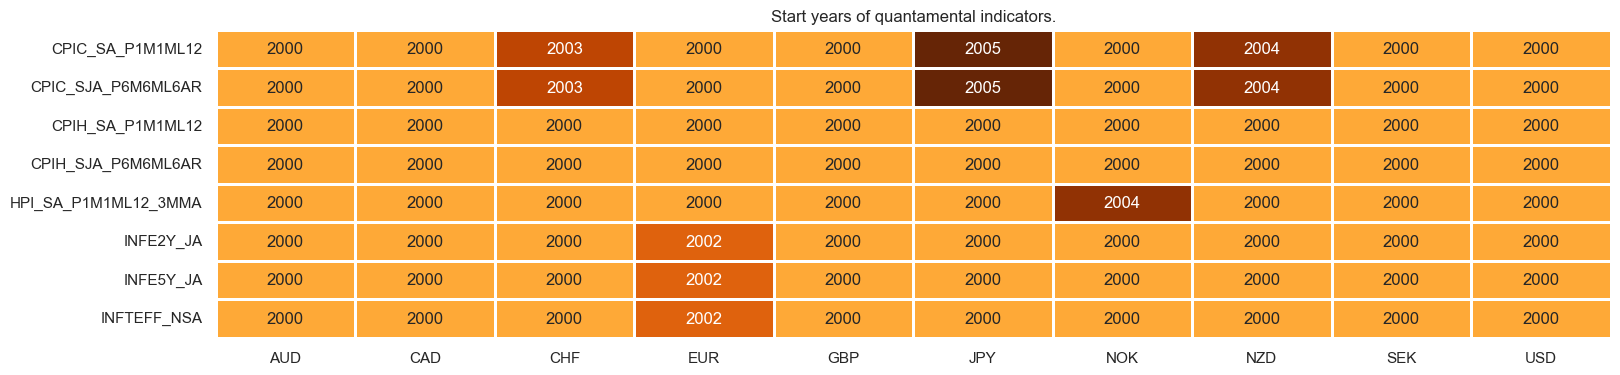

In [13]:
xcatx = sorted(list(set(inflation) - set(non_grata)))
cidx = cids_dm

msm.check_availability(dfx, xcats=xcatx, cids=cidx, missing_recent=False)

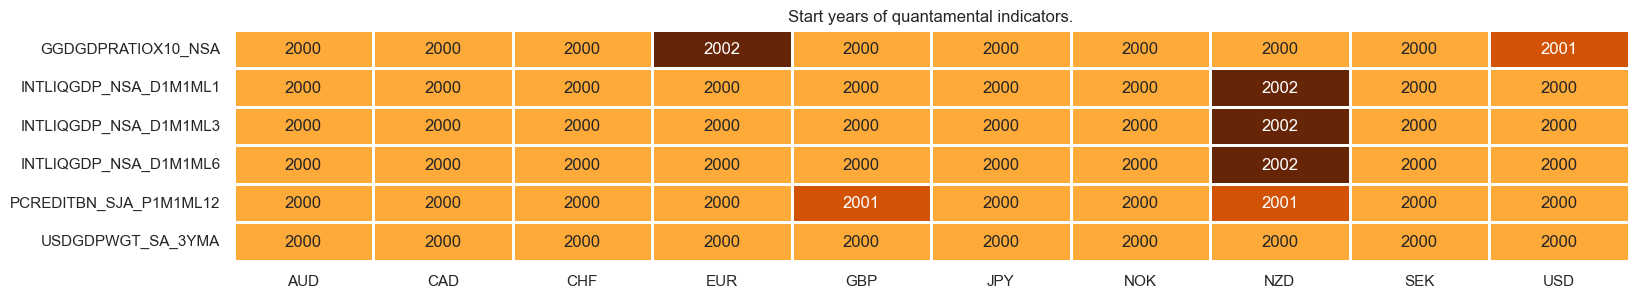

In [14]:
xcatx = sorted(list(set(monliq + fiscal) - set(non_grata)))
cidx = cids_dm

msm.check_availability(dfx, xcats=xcatx, cids=cidx, missing_recent=False)

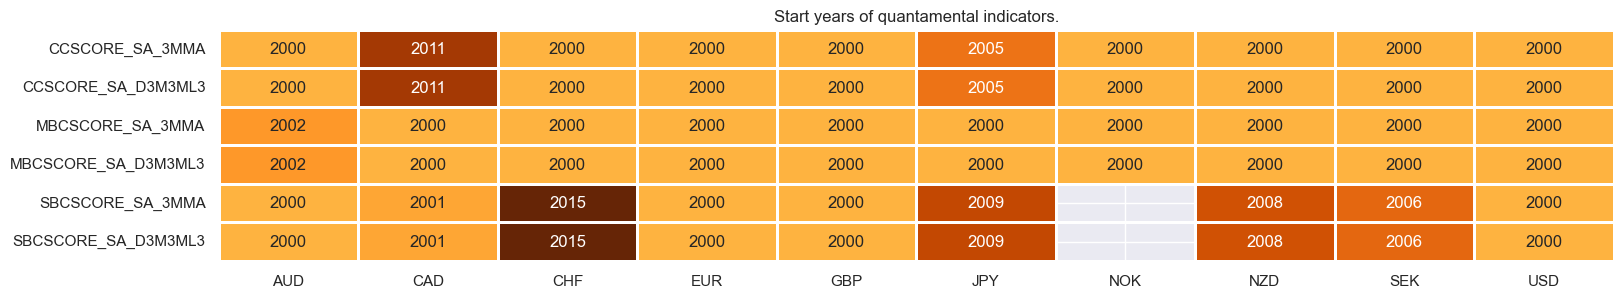

In [15]:
xcatx = sorted(list(set(surveys) - set(non_grata)))
cidx = cids_dm

msm.check_availability(dfx, xcats=xcatx, cids=cidx, missing_recent=False)

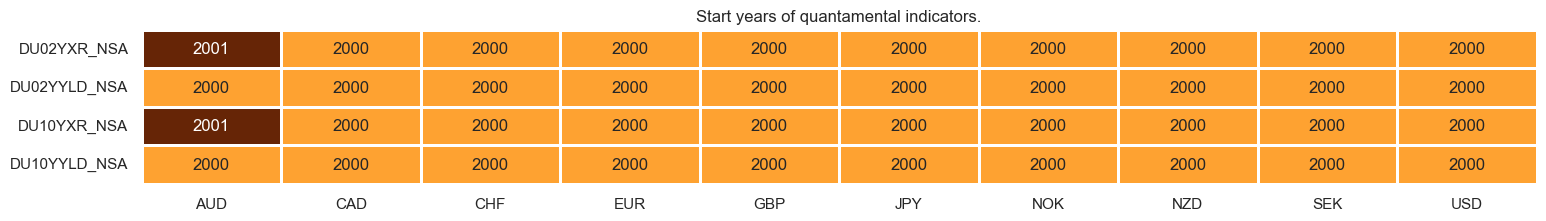

In [16]:
xcatx = sorted(list(set(rets + ylds) - set(non_grata)))
cidx = cids_dm

msm.check_availability(dfx, xcats=xcatx, cids=cidx, missing_recent=False)

## Targets

### Directional IRS return visualization

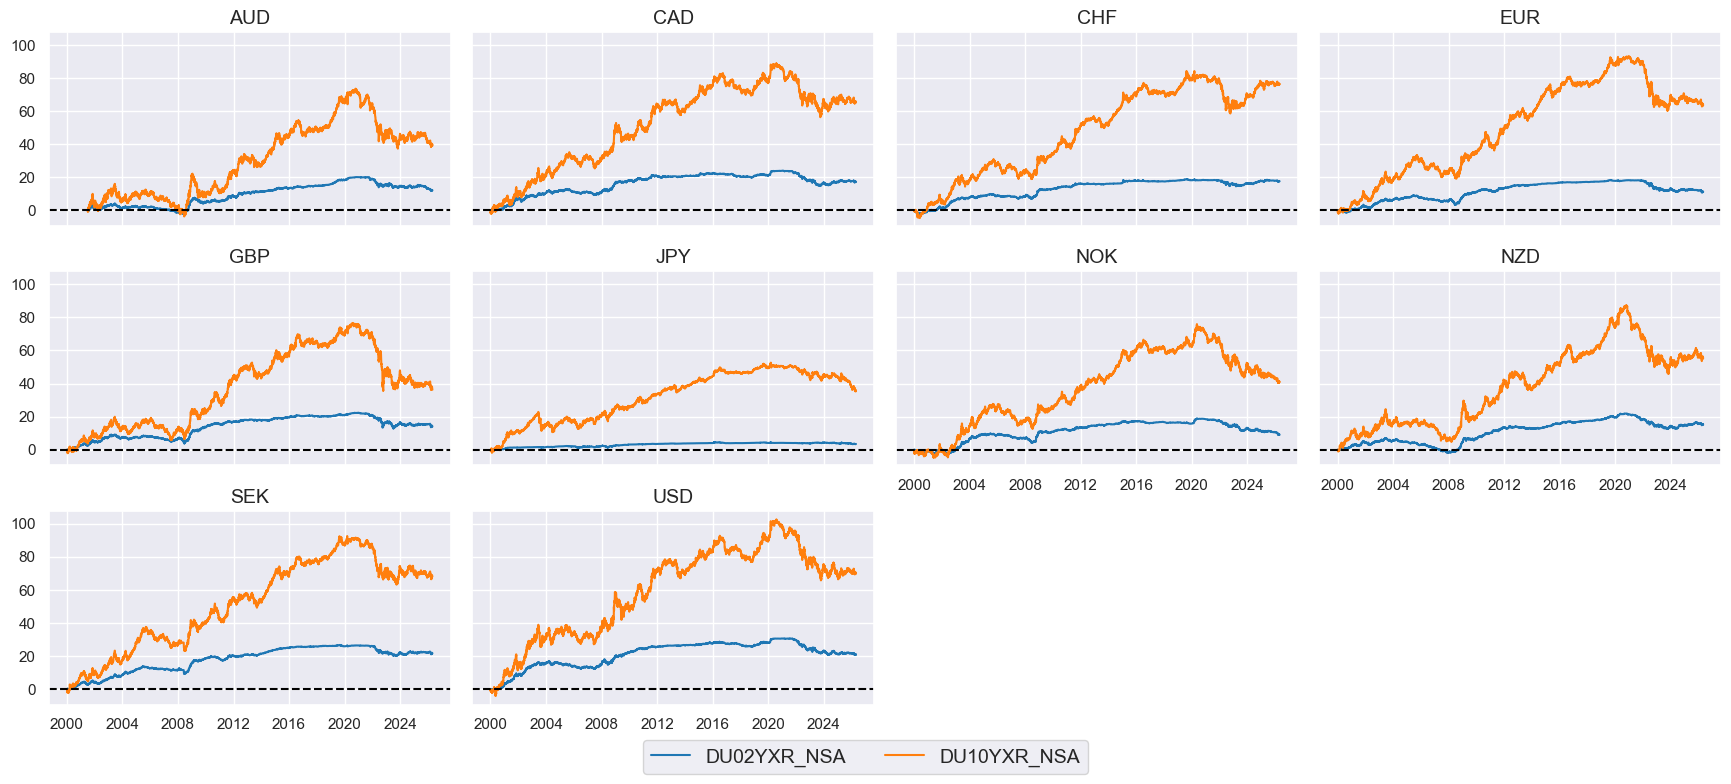

In [17]:
# Directional returns

xcatx = ["DU02YXR_NSA", "DU10YXR_NSA"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    cumsum=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

### DV01-weighted flattening returns

The Annuity factor (continuous-time DV01 proxy) for a T-year par IRS:

`A(T, y) = (1 - exp(-y*T)) / y`

Near-zero yields are floor-ed (eps = 1e-8) to avoid division instability.
The 2-year weight per USD position in the longer tenor is: 

`w = A(T, y_T) / A(2, y_2)`

In [18]:
# DV-01 based flattener return calculation

eps = 1e-8

def annuity_df(x, T, eps=1e-8):
    x_safe = x.where(np.abs(x) >= eps, np.nan)
    out = (1 - np.exp(-x_safe * T)) / x_safe
    return out.where(np.abs(x) >= eps, T)

calcs = [
    "DU02YYLD_DEC = DU02YYLD_NSA / 100",
    "DU10YYLD_DEC = DU10YYLD_NSA / 100",

    "A2 = annuity_df( DU02YYLD_DEC , 2 )",
    "A10 = annuity_df( DU10YYLD_DEC , 10 )",

    "w10v2 = A10 / A2",

    "DU10v02DVXR = DU10YXR_NSA - w10v2 * DU02YXR_NSA",
]

dfa = msp.panel_calculator(
    dfx,
    calcs=calcs,
    cids=cids,
    external_func={"annuity_df": annuity_df},
)

dfx = msm.update_df(dfx, dfa)

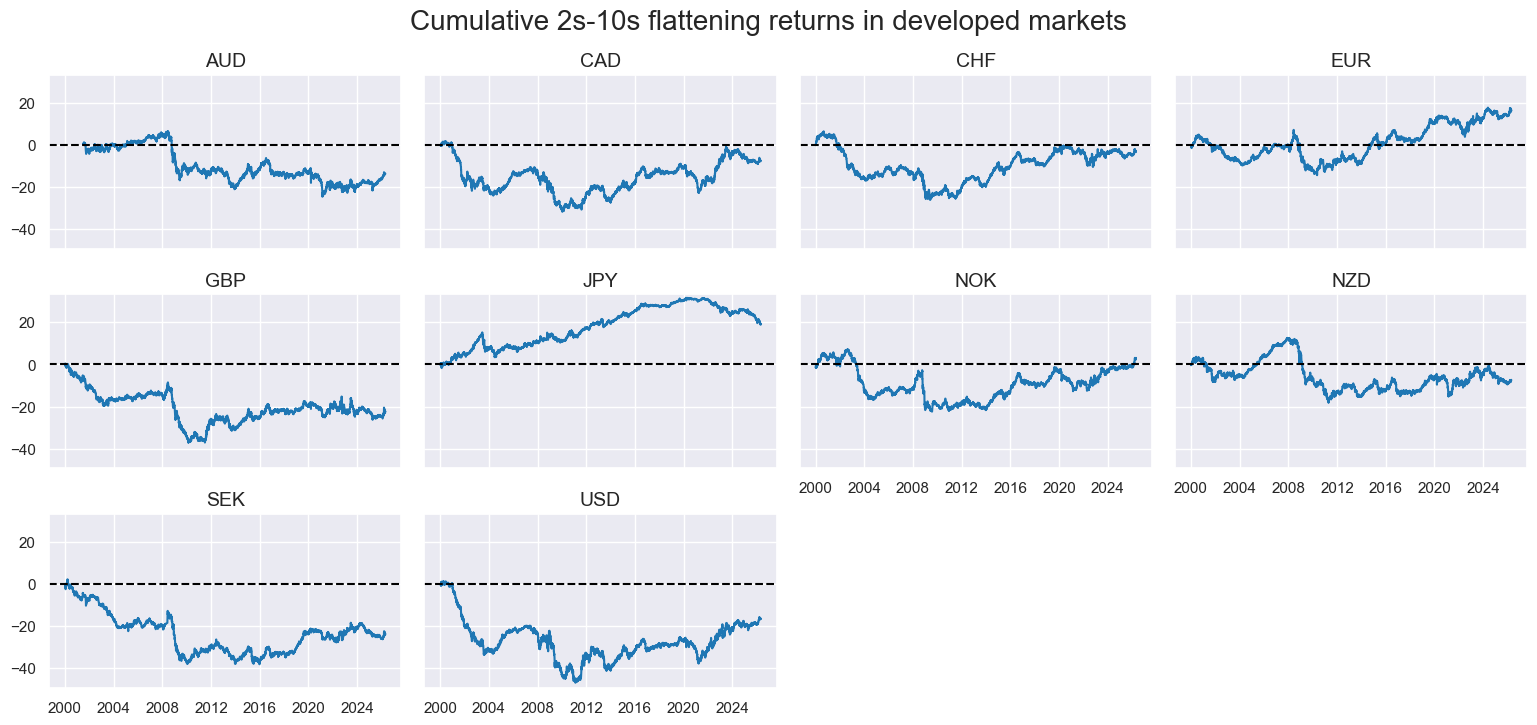

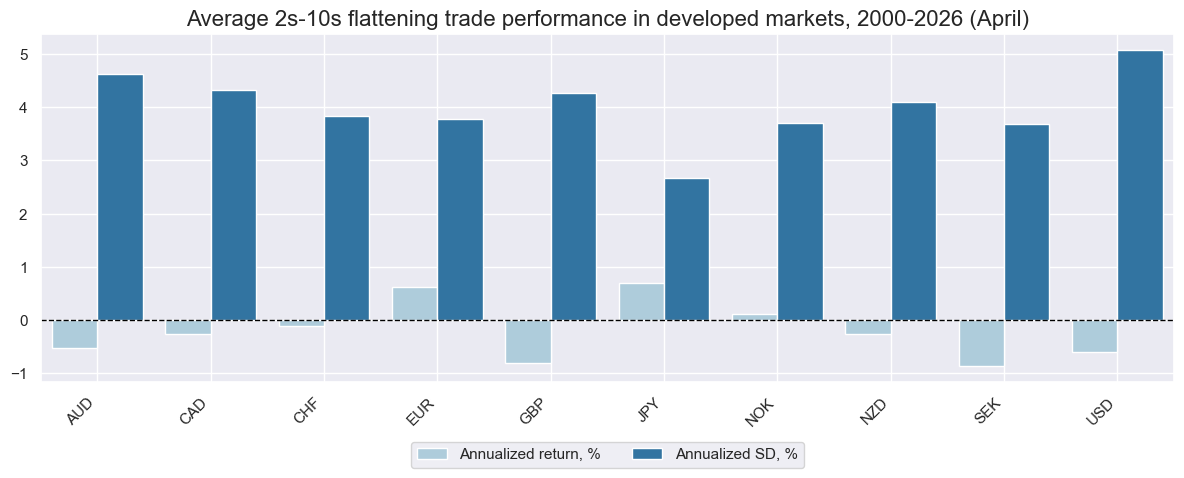

In [19]:
# Visualize DV-01 based flattener returns

xcatx = ["DU10v02DVXR"]
cidx = cids_dm

msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    cumsum=True,
    title="Cumulative 2s-10s flattening returns in developed markets",
    title_fontsize=20,
    height=1.6,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msv.view_performance(
    dfx,
    xcats=xcatx[:1],
    cids=cidx,
    title="Average 2s-10s flattening trade performance in developed markets, 2000-2026 (April)",
    metrics=["Annualized return, %", "Annualized SD, %"],
    size=(12, 5),
)

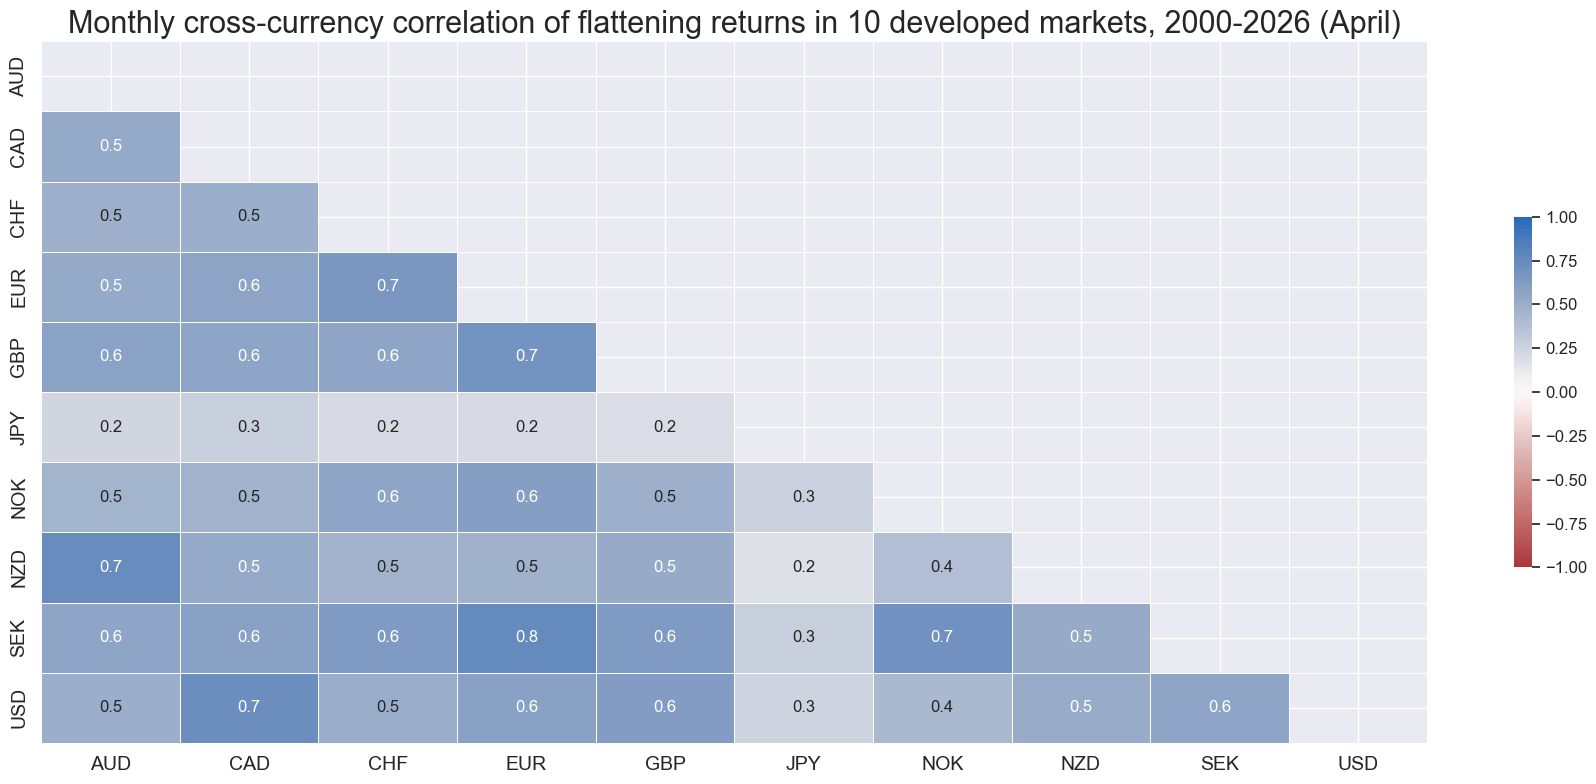

In [20]:
# Cross-correlation

cidx = cids_dm
xcatx = ["DU10v02DVXR"]
start = "2000-01-01"

msp.correl_matrix(
    dfx,
    cids=cidx,
    xcats=xcatx,
    max_color=1.0,
    annot=True, 
    fmt=".1f",
    freq="M",
    cluster=False,
    title="Monthly cross-currency correlation of flattening returns in 10 developed markets, 2000-2026 (April)",
    title_fontsize=22,
    start=start,
    size=(18, 8)
)

## Features

### Labor market tightening and tightness

In [21]:
# Labor market constituents calculations

calcs = [
    "XEMPL_NSA_P1M1ML12_3MMA = EMPL_NSA_P1M1ML12_3MMA - WFORCE_NSA_P1Y1YL1_5YMM ",
    "UNEMPLRATE_SA_3MMAv10YMM_NEG = - UNEMPLRATE_SA_3MMAv10YMM",
]
dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cids)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

labtights = list(dfa["xcat"].unique())

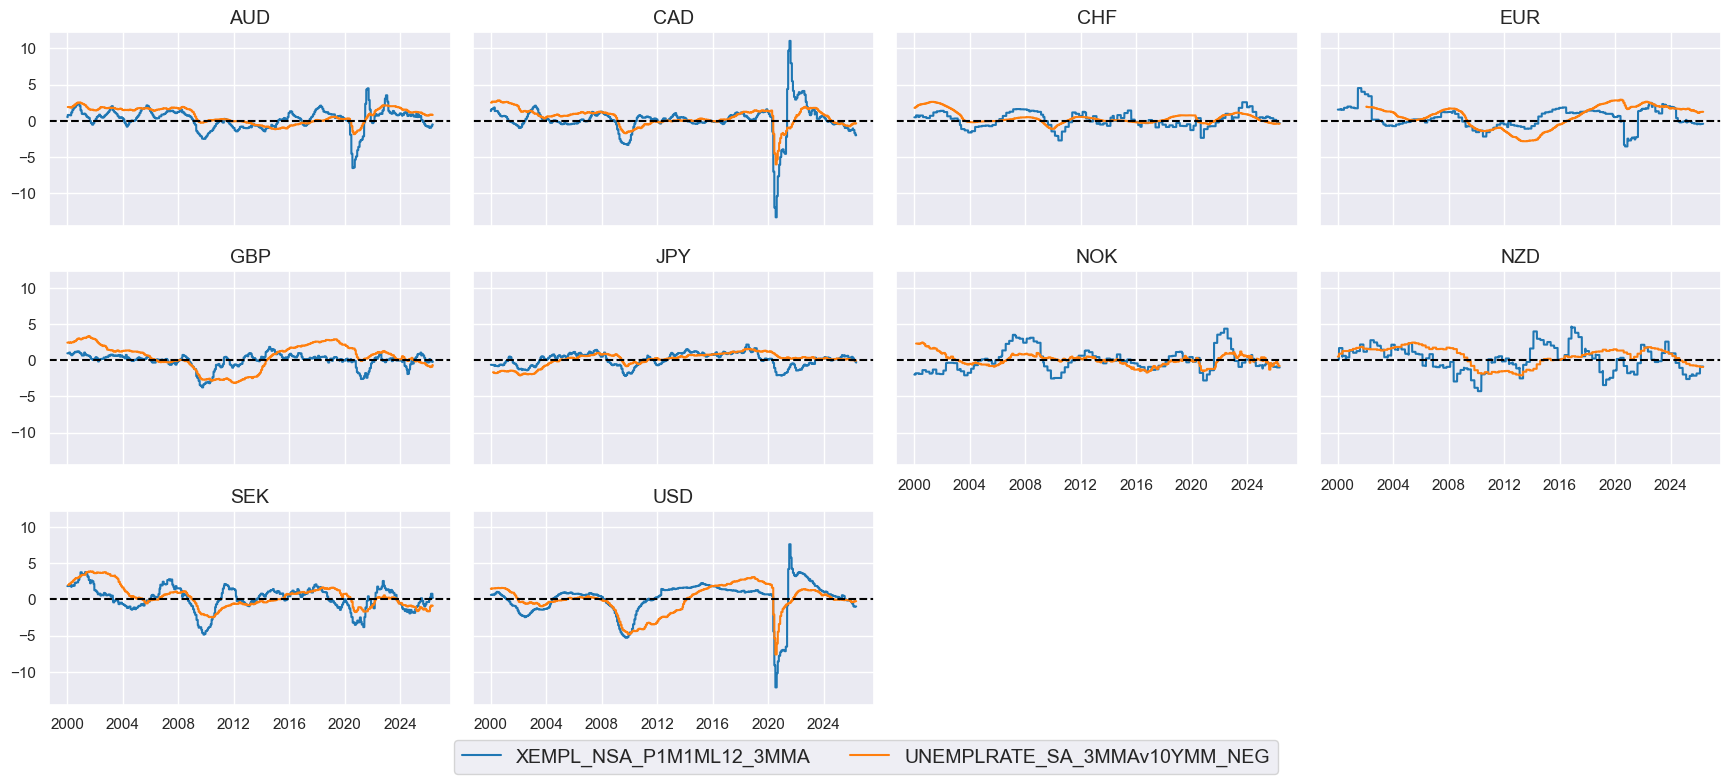

In [22]:
# Labor market constituents visualization

xcatx = labtights
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [23]:
# Labor market constituents scoring

xcatx = labtights
cidx = cids_dm

for xc in xcatx:
    dfa = msp.make_zn_scores(
        dfx,
        xcat=xc,
        cids=cidx,
        sequential=True,
        min_obs=522,  # oos scaling after 2 years of panel data
        est_freq="m",
        neutral="zero",
        pan_weight=1,
        thresh=3,
        postfix="_ZN",
    )
    dfx = msm.update_df(dfx, dfa, xcat_replace=True)

labtightz = [xc + "_ZN" for xc in labtights]

In [24]:
# Labor market combined factor score

xcatx = labtightz
cidx = cids_dm

# Linear combination of whatever is available

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="LABTIGHT",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-scoring of composite factor

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

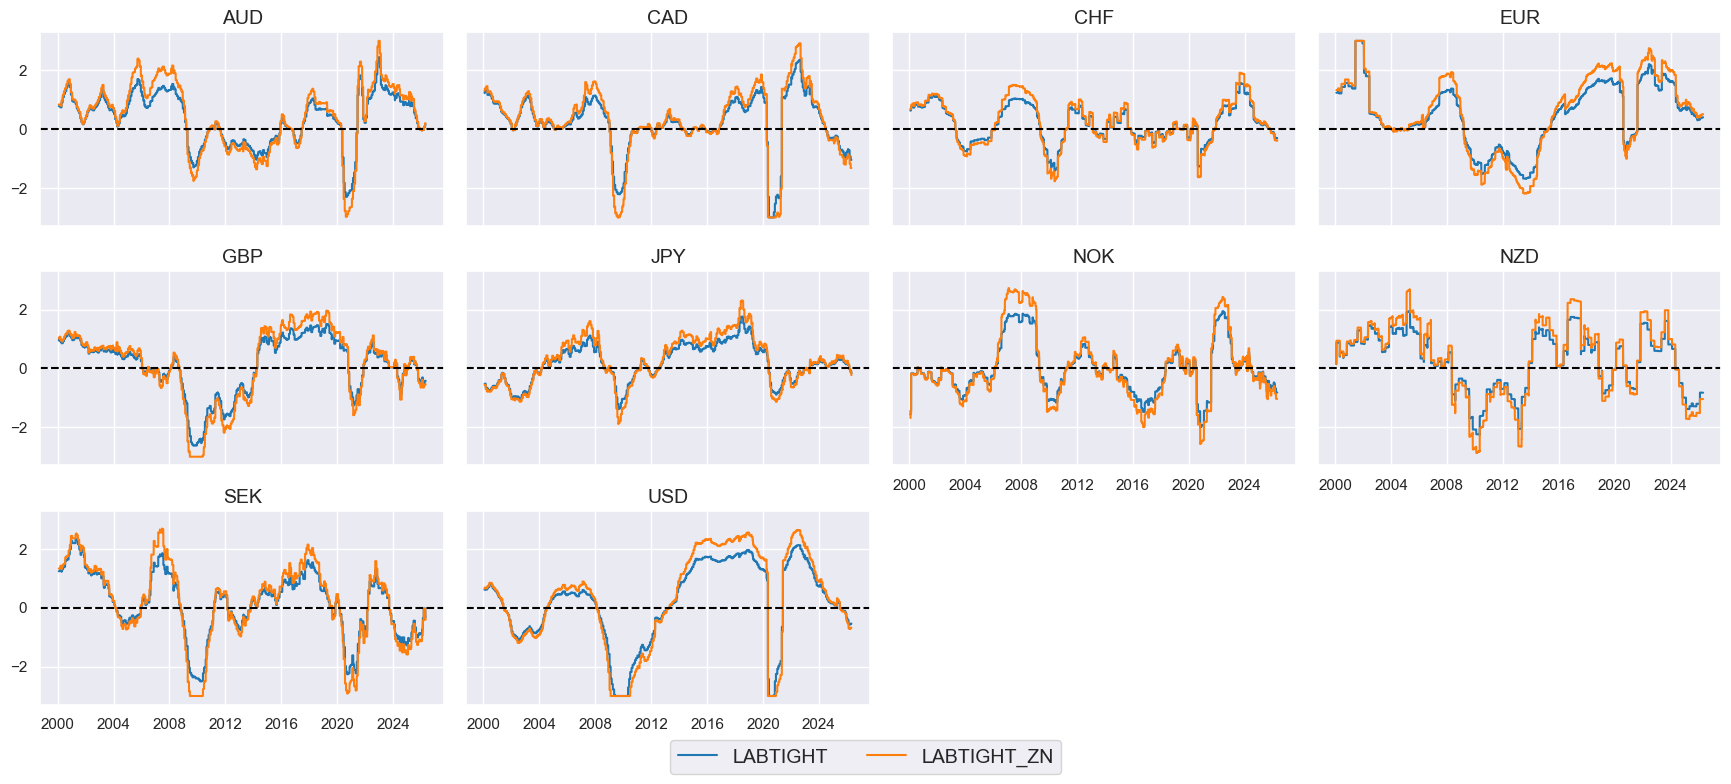

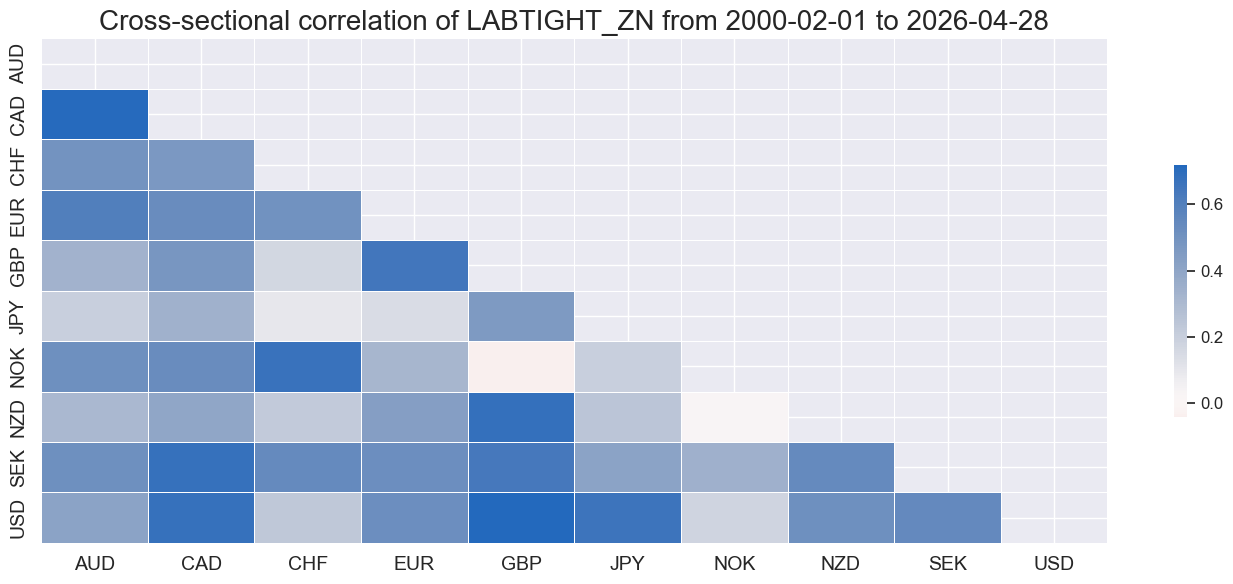

In [25]:
# Labor market factor visualization

xcatx = ["LABTIGHT", "LABTIGHT_ZN"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Excess CPI inflation

In [26]:
# CPI inflation constituents calculations

infs = [
    "CPIH_SA_P1M1ML12",
    "CPIH_SJA_P6M6ML6AR",
    "CPIC_SA_P1M1ML12",
    "CPIC_SJA_P6M6ML6AR",
]

calcs = [f"{inf}vIET = ( {inf} - INFTEFF_NSA )" for inf in infs]
dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cids)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

xinfs = list(dfa["xcat"].unique())

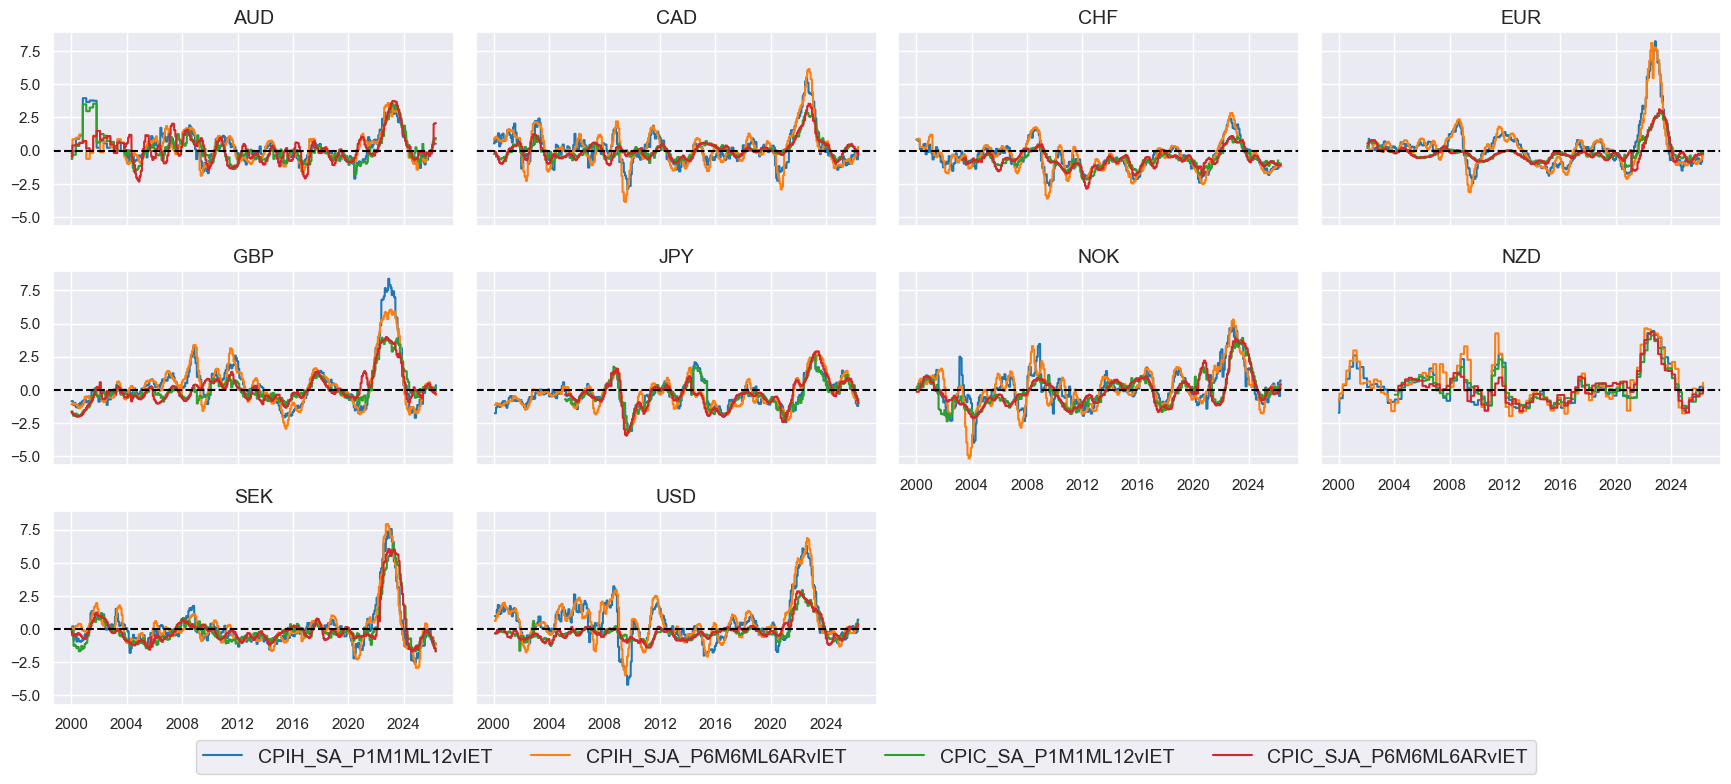

In [27]:
# CPI inflation constituents visualization

xcatx = xinfs
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [28]:
# CPI inflation constituents scoring

xcatx = xinfs
cidx = cids_dm

for xc in xcatx:
    dfa = msp.make_zn_scores(
        dfx,
        xcat=xc,
        cids=cidx,
        sequential=True,
        min_obs=522,  # oos scaling after 2 years of panel data
        est_freq="m",
        neutral="zero",
        pan_weight=1,
        thresh=3,
        postfix="_ZN",
    )
    dfx = msm.update_df(dfx, dfa, xcat_replace=True)

xinfz = [xc + "_ZN" for xc in xinfs]

In [29]:
# CPI inflation combined factor score

xcatx = xinfz
cidx = cids_dm

# Linear combination of whatever is available

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="XINF",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-scoring of composite factor

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

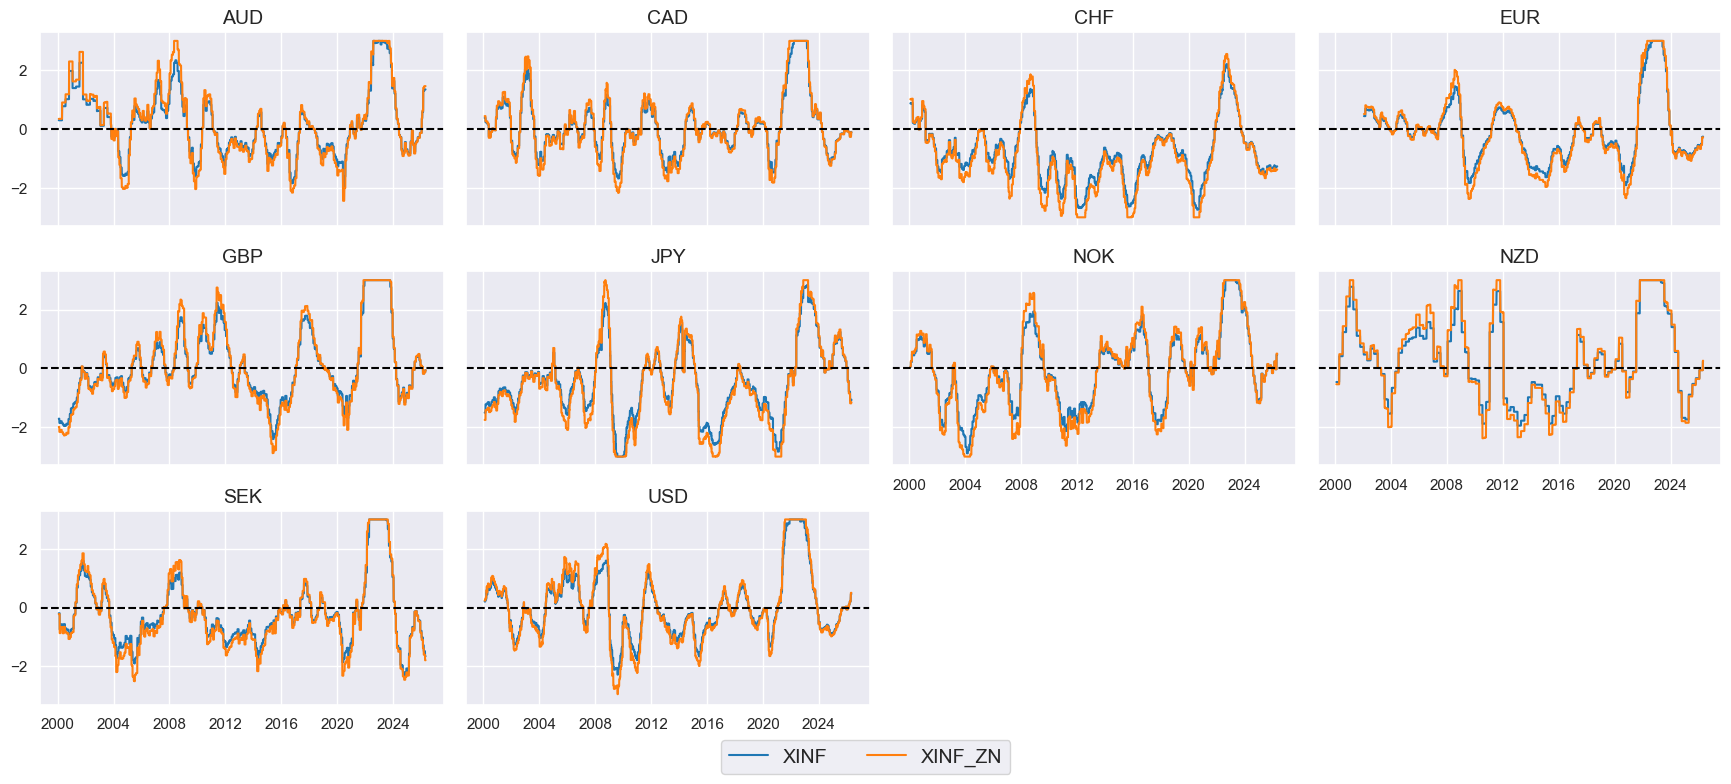

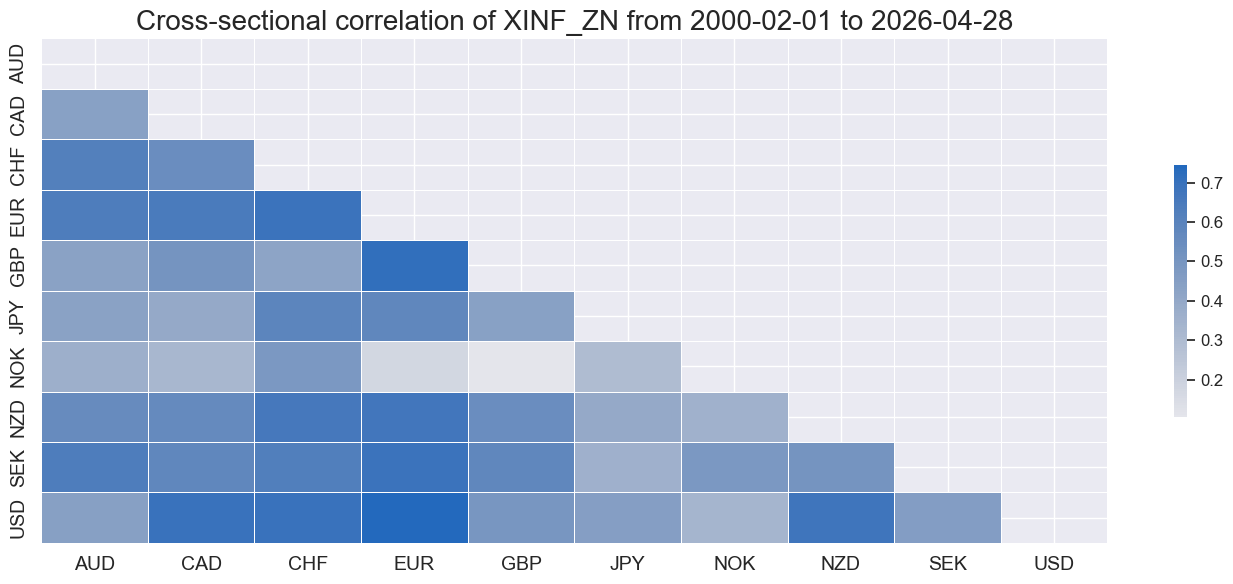

In [30]:
# CPI inflation factor visualization

xcatx = ["XINF", "XINF_ZN"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Excess financial expansion

In [31]:
# Finance constituents calculations

calcs = [
    "LTNOMGROWTH = INFTEFF_NSA + RGDP_SA_P1Q1QL4_20QMM",
    "XPCREDIT_P1M1ML12 = PCREDITBN_SJA_P1M1ML12 - LTNOMGROWTH",
    "XHPI_P1M1ML12_3MMA = HPI_SA_P1M1ML12_3MMA - LTNOMGROWTH",
         ]
dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cids)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

xfins = [xc for xc in list(dfa["xcat"].unique()) if xc.startswith("X")]

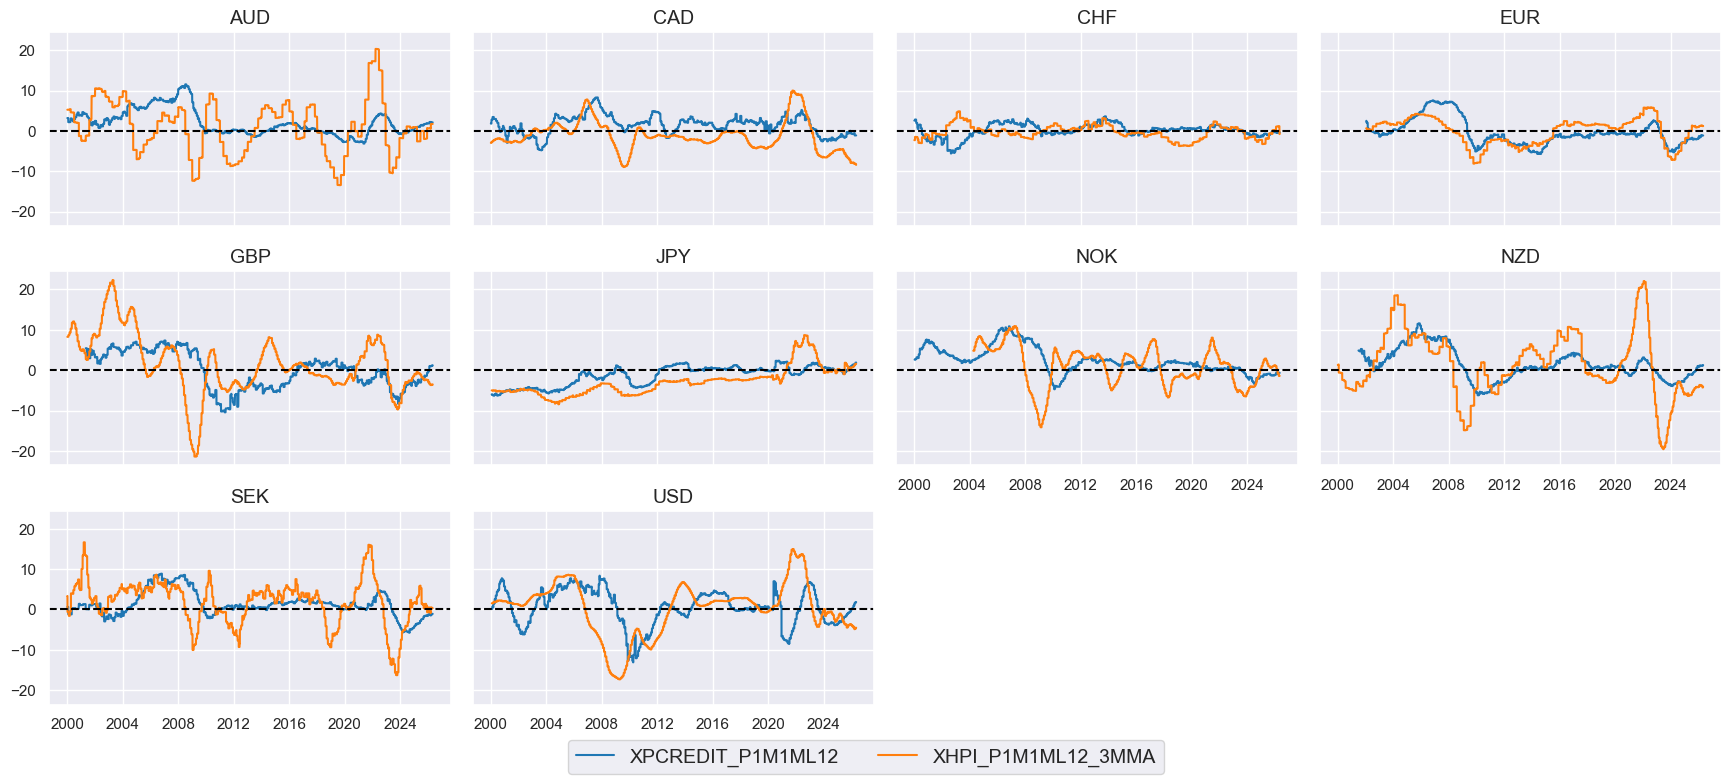

In [32]:
# Finance constituents visualization

xcatx = xfins
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [33]:
# Finance constituents scoring

xcatx = xfins
cidx = cids_dm

for xc in xcatx:
    dfa = msp.make_zn_scores(
        dfx,
        xcat=xc,
        cids=cidx,
        sequential=True,
        min_obs=522,  # oos scaling after 2 years of panel data
        est_freq="m",
        neutral="zero",
        pan_weight=1,
        thresh=3,
        postfix="_ZN",
    )
    dfx = msm.update_df(dfx, dfa, xcat_replace=True)

xfinz = [xc + "_ZN" for xc in xfins]

In [34]:
# Finance combined factor score

xcatx = xfinz
cidx = cids_dm

# Linear combination of whatever is available

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="XFIN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-scoring of composite factor

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

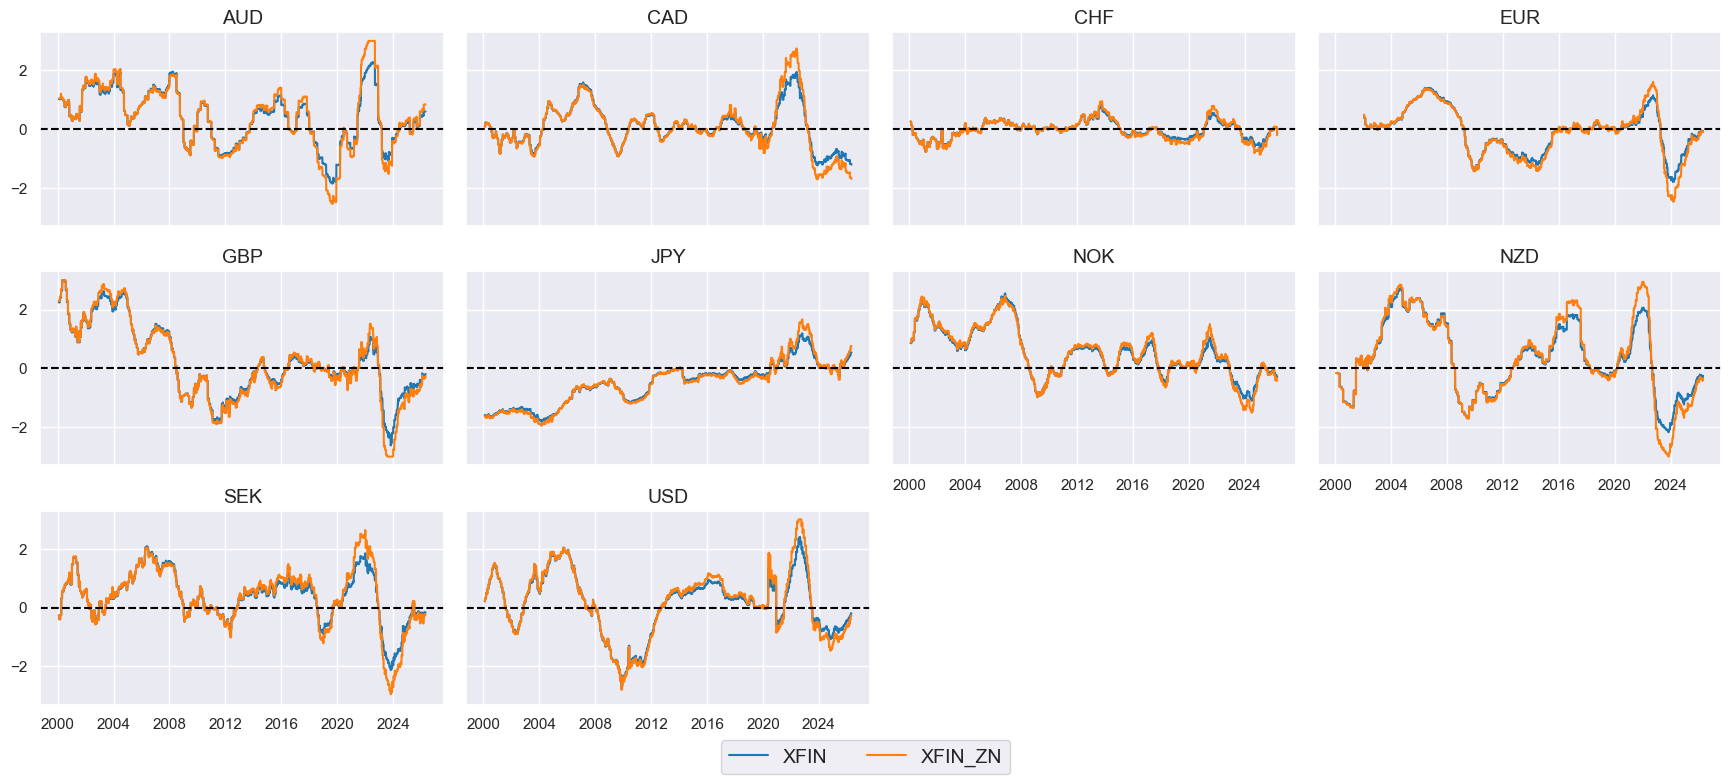

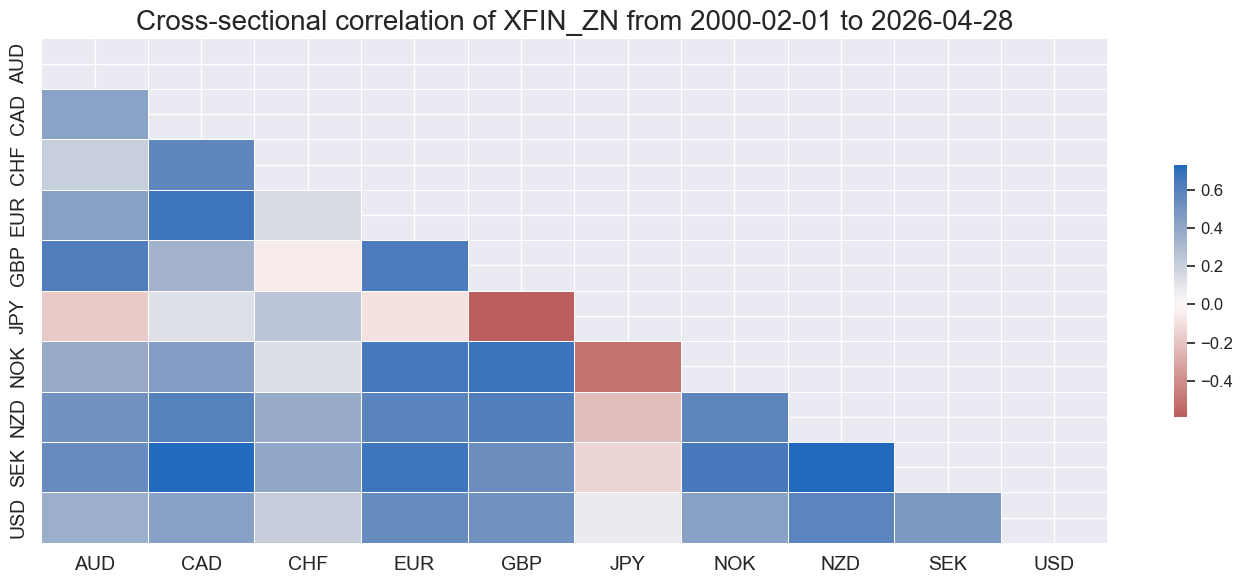

In [35]:
# Excess financial expansion factor visualization

xcatx = ["XFIN", "XFIN_ZN"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Activity overheating

In [36]:
# Overheating constituents calculations

calcs = [
    "XIMPORTS_SA_P1M1ML12_3MMA = IMPORTS_SA_P1M1ML12_3MMA - RGDP_SA_P1Q1QL4_20QMM - INFTEFF_NSA",
    "XNRSALES_SA_P1M1ML12_3MMA = NRSALES_SA_P1M1ML12_3MMA - RGDP_SA_P1Q1QL4_20QMM - INFTEFF_NSA",
    "XRRSALES_SA_P1M1ML12_3MMA = RRSALES_SA_P1M1ML12_3MMA - RGDP_SA_P1Q1QL4_20QMM",
    "XRPCONS_SA_P1M1ML12_3MMA = RPCONS_SA_P1M1ML12_3MMA - RGDP_SA_P1Q1QL4_20QMM",
    "XRGDPTECH_SA_P1M1ML12_3MMA = RGDPTECH_SA_P1M1ML12_3MMA - RGDP_SA_P1Q1QL4_20QMM",
    "XINTRGDP_NSA_P1M1ML12_3MMA = INTRGDP_NSA_P1M1ML12_3MMA - RGDP_SA_P1Q1QL4_20QMM",
]

dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cids)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

overheats = list(dfa["xcat"].unique())

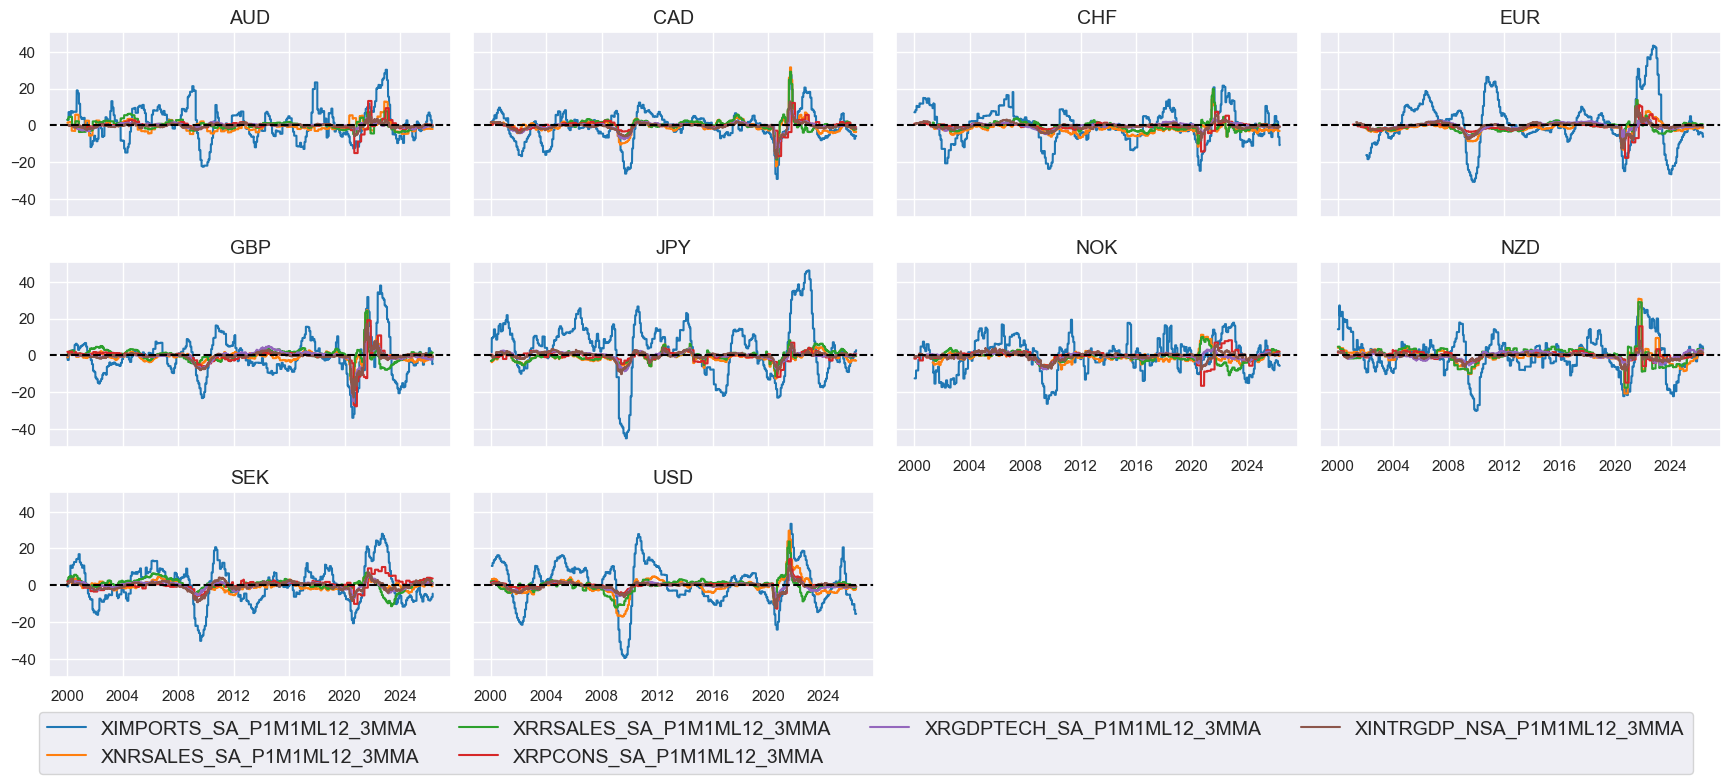

In [37]:
# Overheating constituents visualization

xcatx = overheats
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [38]:
# Overheating constituents scoring

xcatx = overheats
cidx = cids_dm

for xc in xcatx:
    dfa = msp.make_zn_scores(
        dfx,
        xcat=xc,
        cids=cidx,
        sequential=True,
        min_obs=522,  # oos scaling after 2 years of panel data
        est_freq="m",
        neutral="zero",
        pan_weight=1,
        thresh=3,
        postfix="_ZN",
    )
    dfx = msm.update_df(dfx, dfa, xcat_replace=True)

overheatz= [xc + "_ZN" for xc in overheats]

In [39]:
# Overheating combined factor score

xcatx = overheatz
cidx = cids_dm

# Linear combination of whatever is available

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="OVERHEAT",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-scoring of composite factor

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

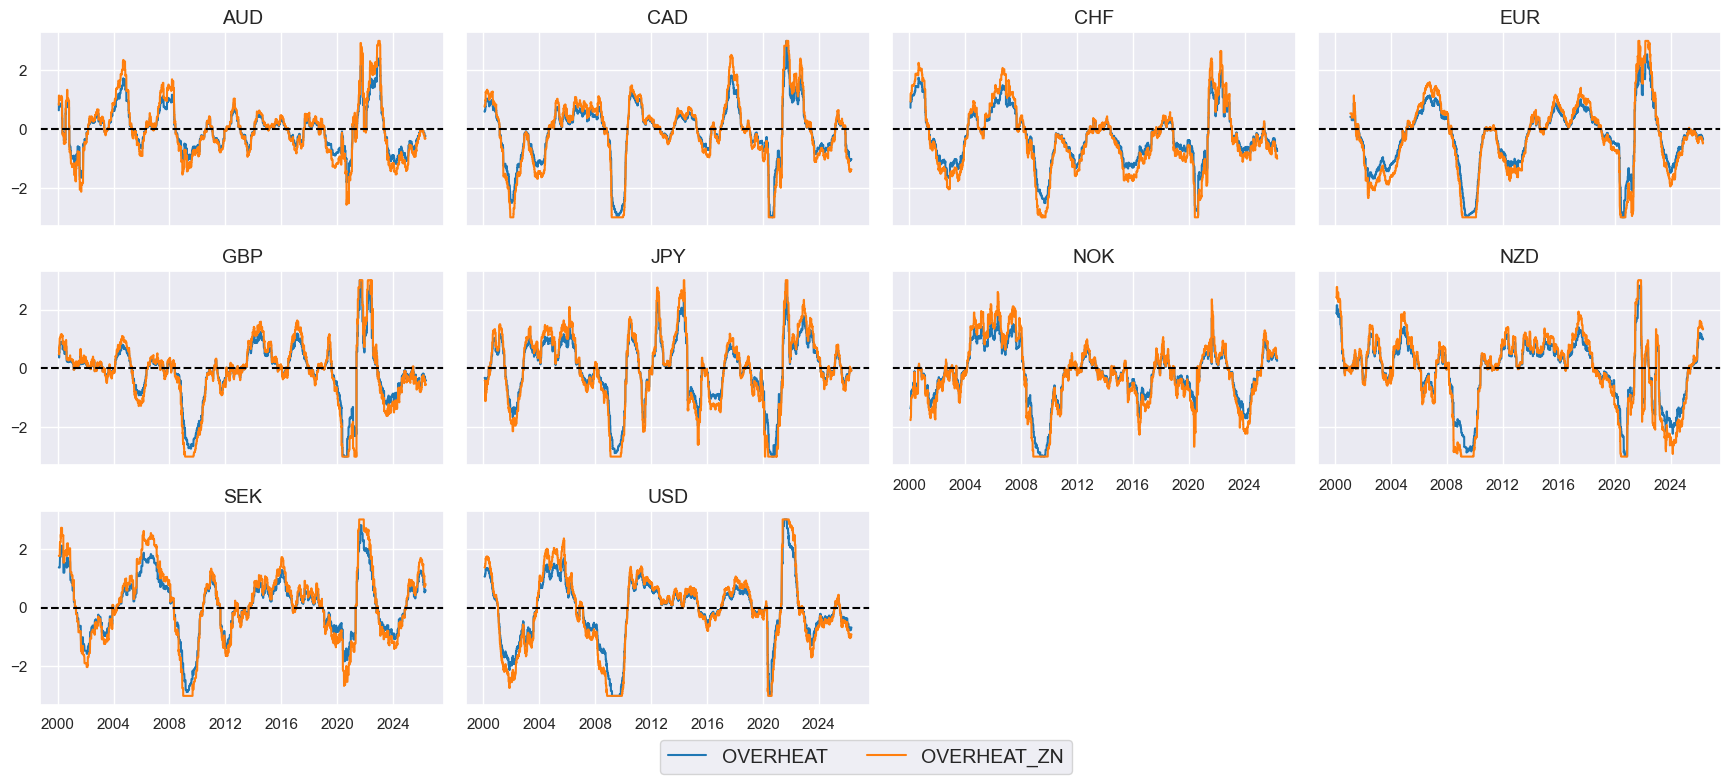

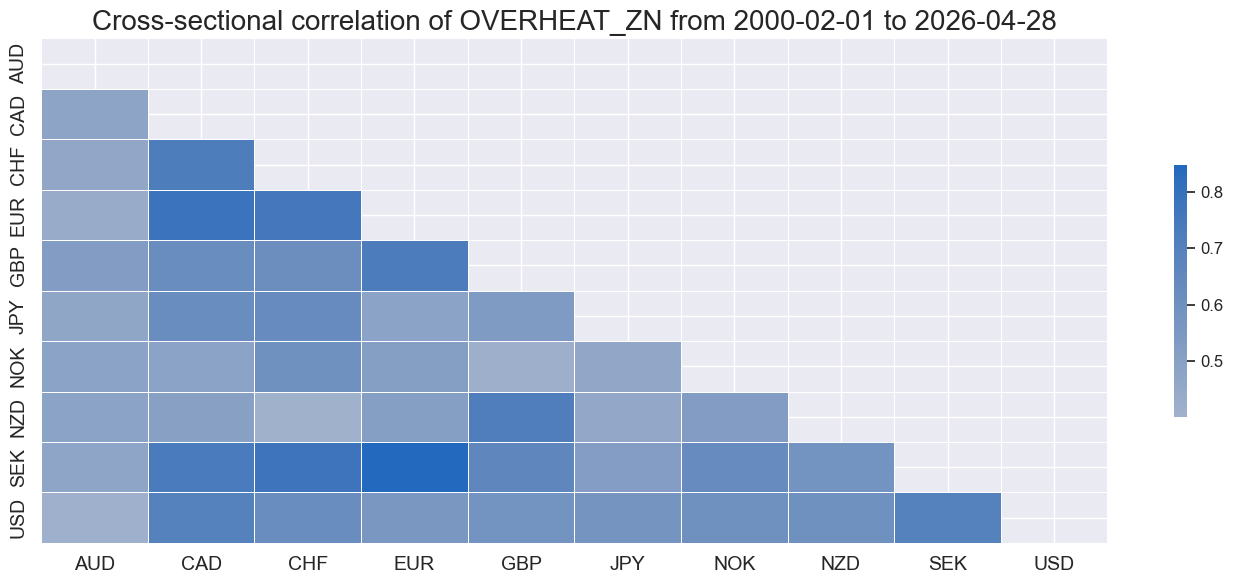

In [40]:
# Overheating factor visualization

xcatx = ["OVERHEAT", "OVERHEAT_ZN"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Public debt sustainability improvement

In [41]:
# Public debt improvement constituents calculations

xcat_fsc = "GGDGDPRATIOX10_NSA"

dict_trends = {
    "DM": {"short": 1, "long": 21, "thresh": 10},
    "WQ": {"short": 5, "long": 63, "thresh": 15},
    "MY": {"short": 21, "long": 252, "thresh": 20},
}

calcs = []
fiscals = []

for params in dict_trends.values():
    raw = f"{xcat_fsc}_{params['short']}Dv{params['long']}D"
    win = raw + f"W{params['thresh']}"
    calcs.append(
        f"{raw} = {xcat_fsc}.rolling({params['short']}).mean() - "
        f"{xcat_fsc}.shift({params['short']}).rolling({params['long']}).mean()"
    )
    calcs.append(
        f"{win}_NEG = - {raw}.clip(lower=-{params['thresh']}, upper={params['thresh']})"
    )
    fiscals.append(win+"_NEG")

dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cids)
dfx = msm.update_df(dfx, dfa)

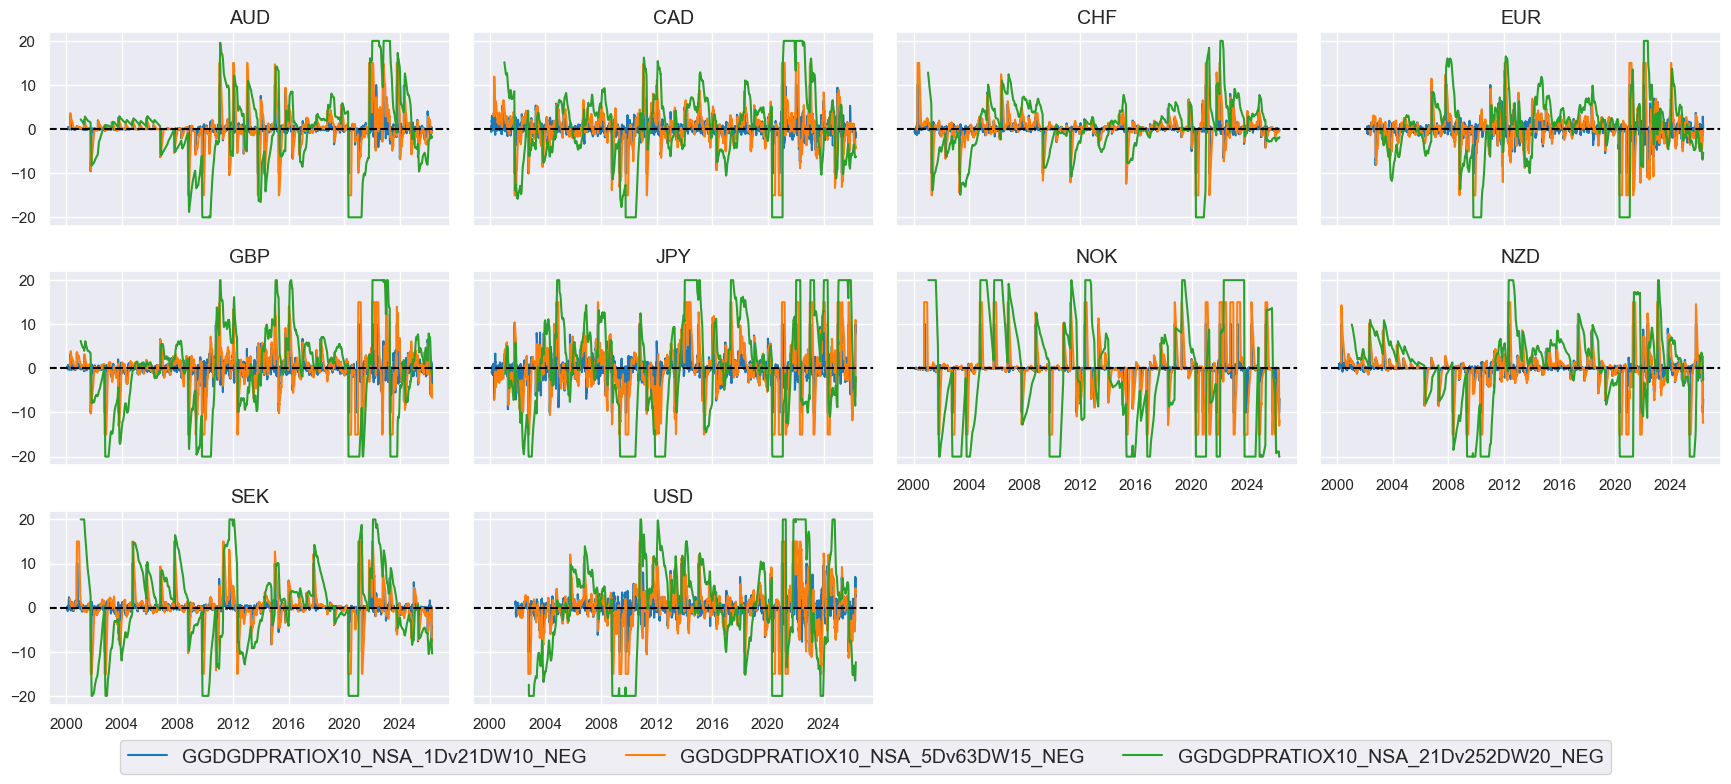

In [42]:
# Public debt improvement constituents visualization

xcatx = fiscals
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [43]:
# Public debt improvement constituents scoring

xcatx = fiscals
cidx = cids_dm

for xc in xcatx:
    dfa = msp.make_zn_scores(
        dfx,
        xcat=xc,
        cids=cidx,
        sequential=True,
        min_obs=522,  # oos scaling after 2 years of panel data
        est_freq="m",
        neutral="zero",
        pan_weight=1,
        thresh=3,
        postfix="_ZN",
    )
    dfx = msm.update_df(dfx, dfa, xcat_replace=True)

fiscalz = [xc + "_ZN" for xc in fiscals]

In [44]:
# Public debt improvement combined factor score

xcatx = fiscalz
cidx = cids_dm

# Linear combination of whatever is available

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="DEBTIMPROVE",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-scoring of composite factor

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

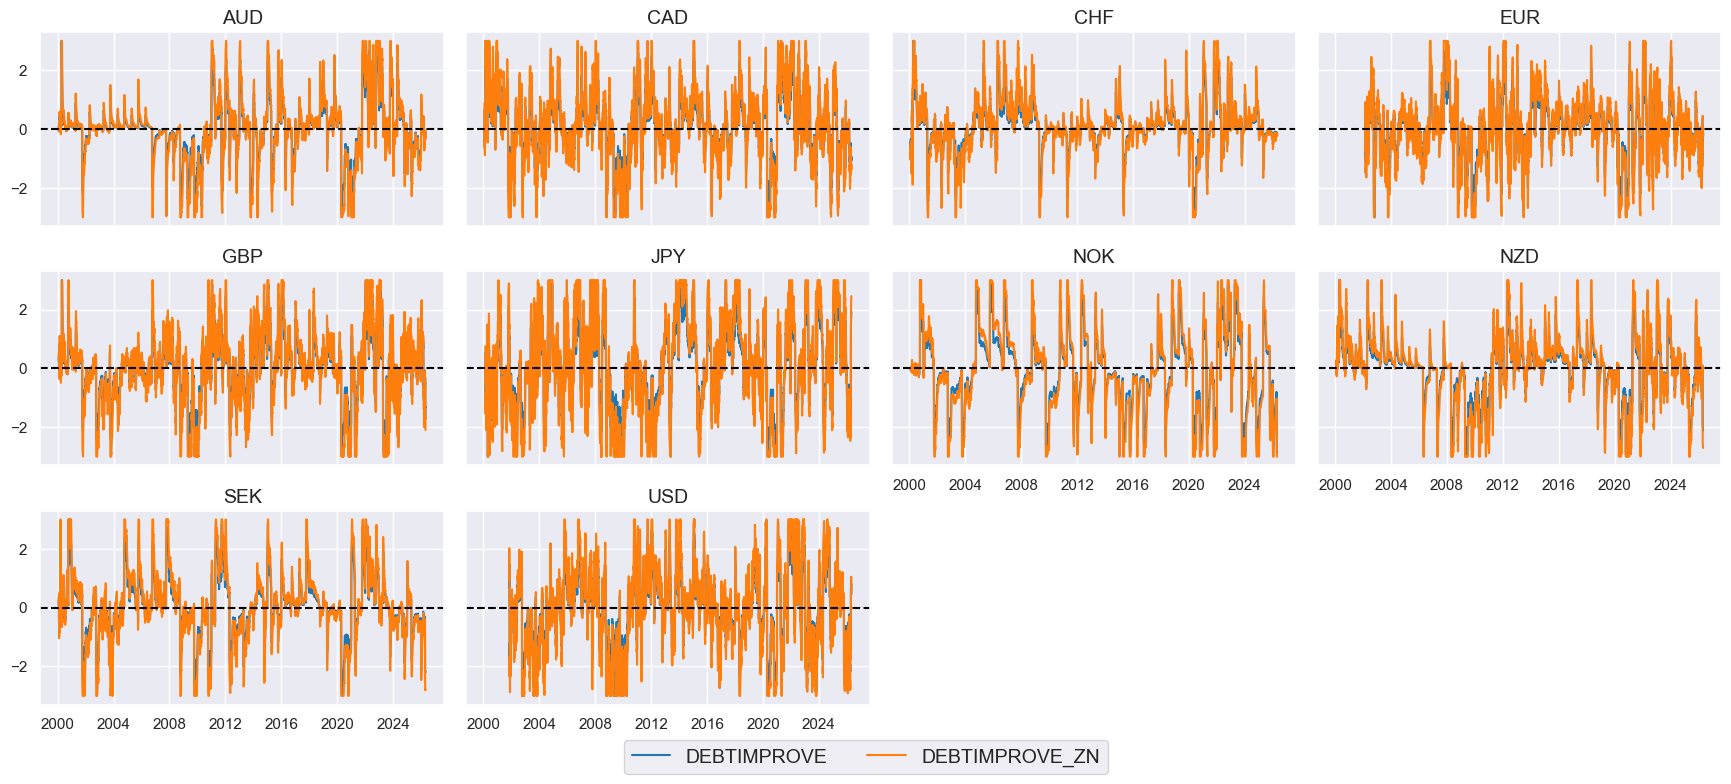

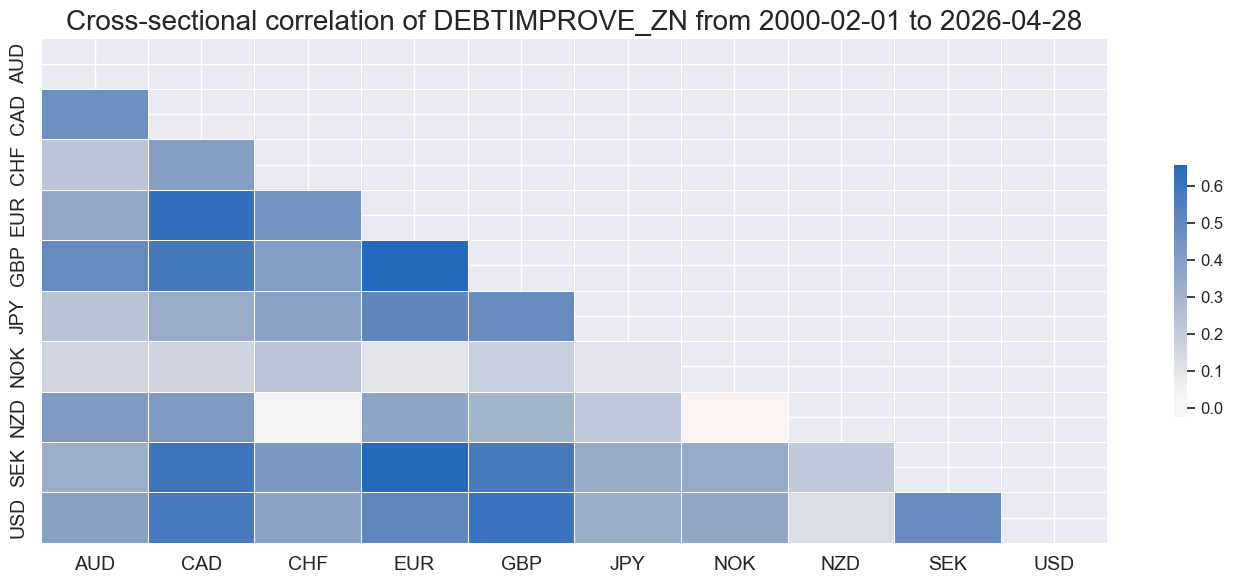

In [45]:
# Public debt improvement factor visualization

xcatx = ["DEBTIMPROVE", "DEBTIMPROVE_ZN"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Economic confidence scores

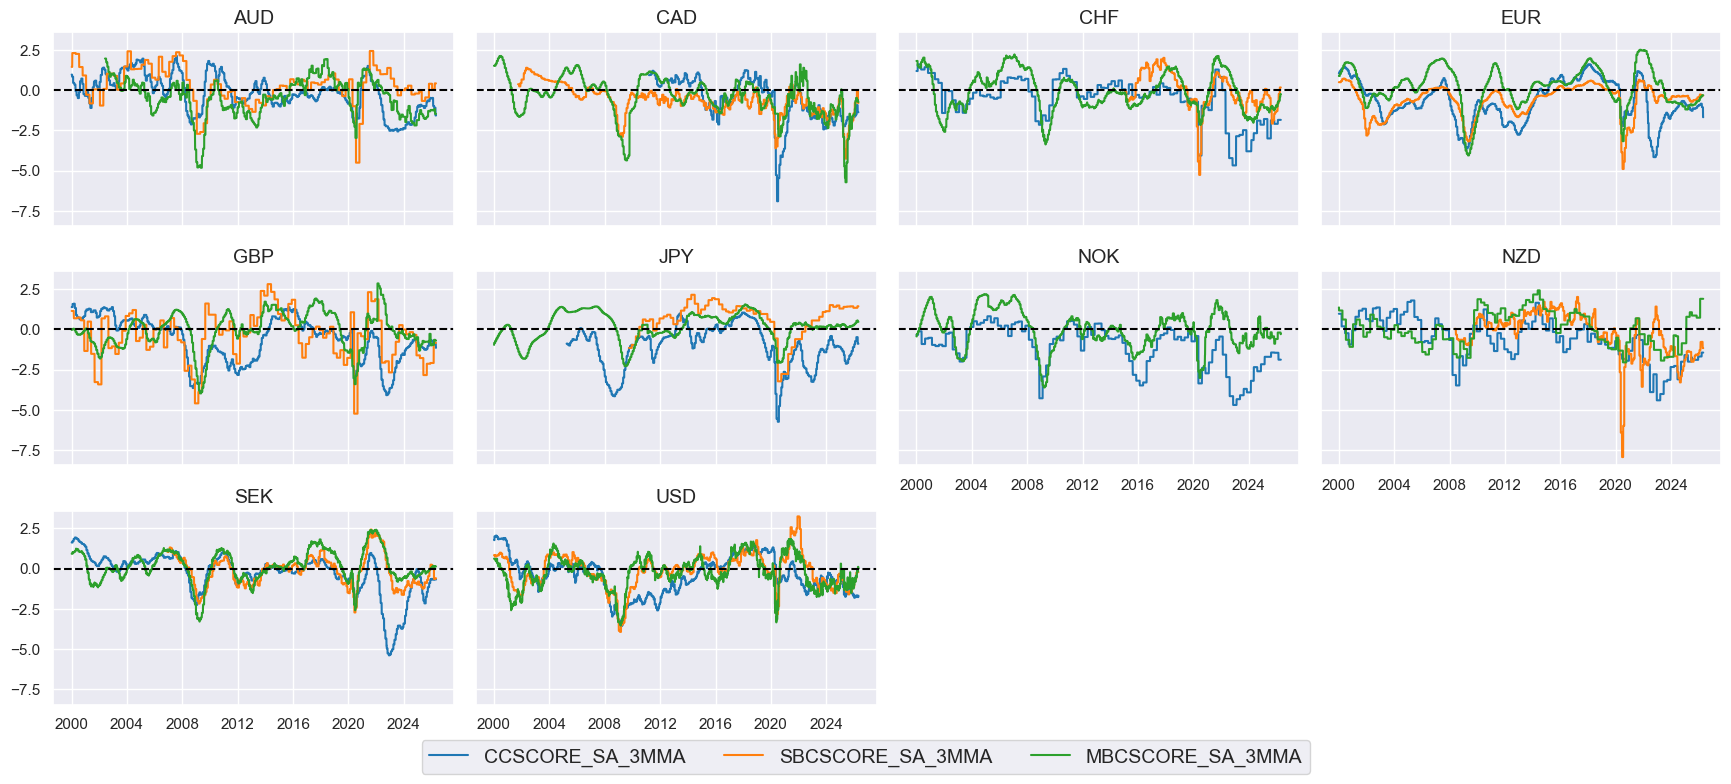

In [46]:
# Confidence score constituents visualization

confs = [s for s in surveys if s.endswith("3MMA")]

xcatx = confs
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [47]:
# Confidence combined factor score

xcatx = confs
cidx = cids_dm

# Linear combination of whatever is available

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="CONFLEVEL",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-scoring of composite factor

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

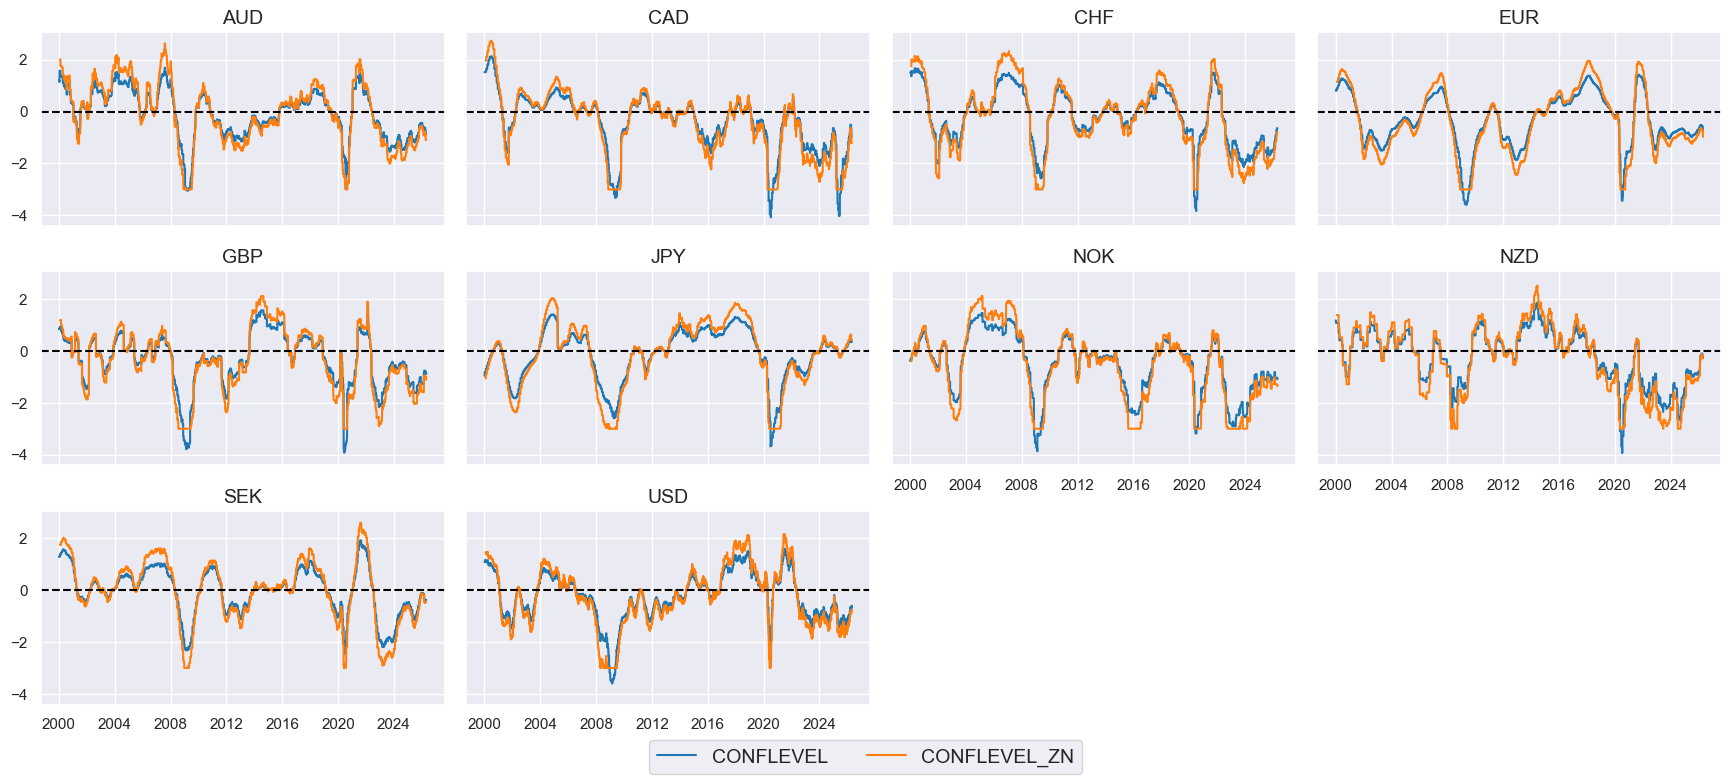

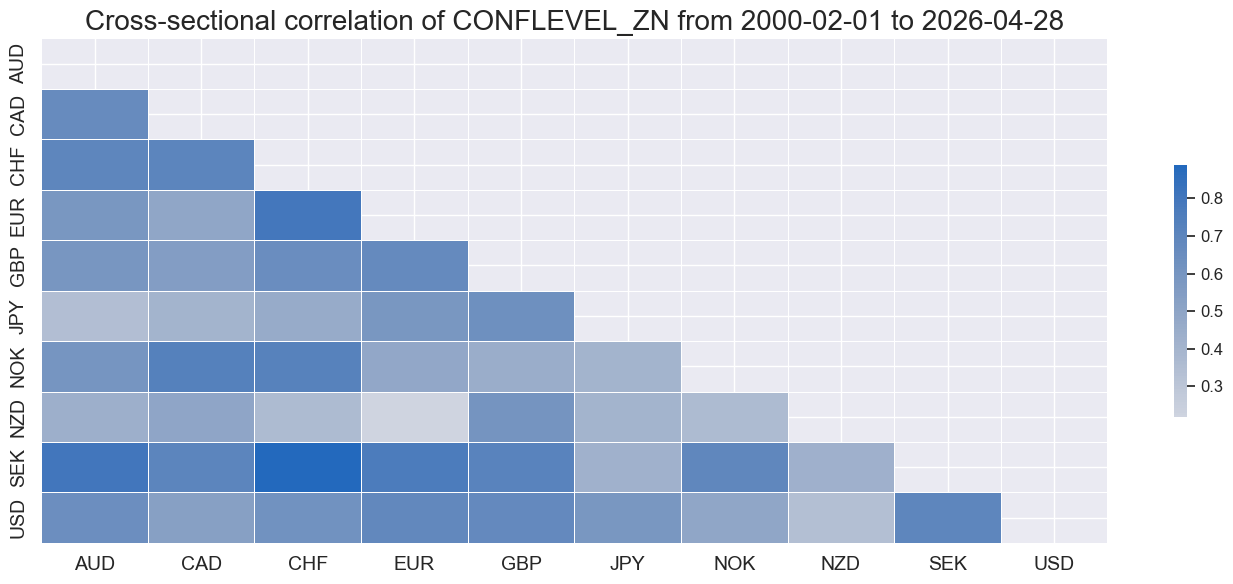

In [48]:
# Economic confidence factor visualization

xcatx = ["CONFLEVEL", "CONFLEVEL_ZN"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Economic confidence improvement

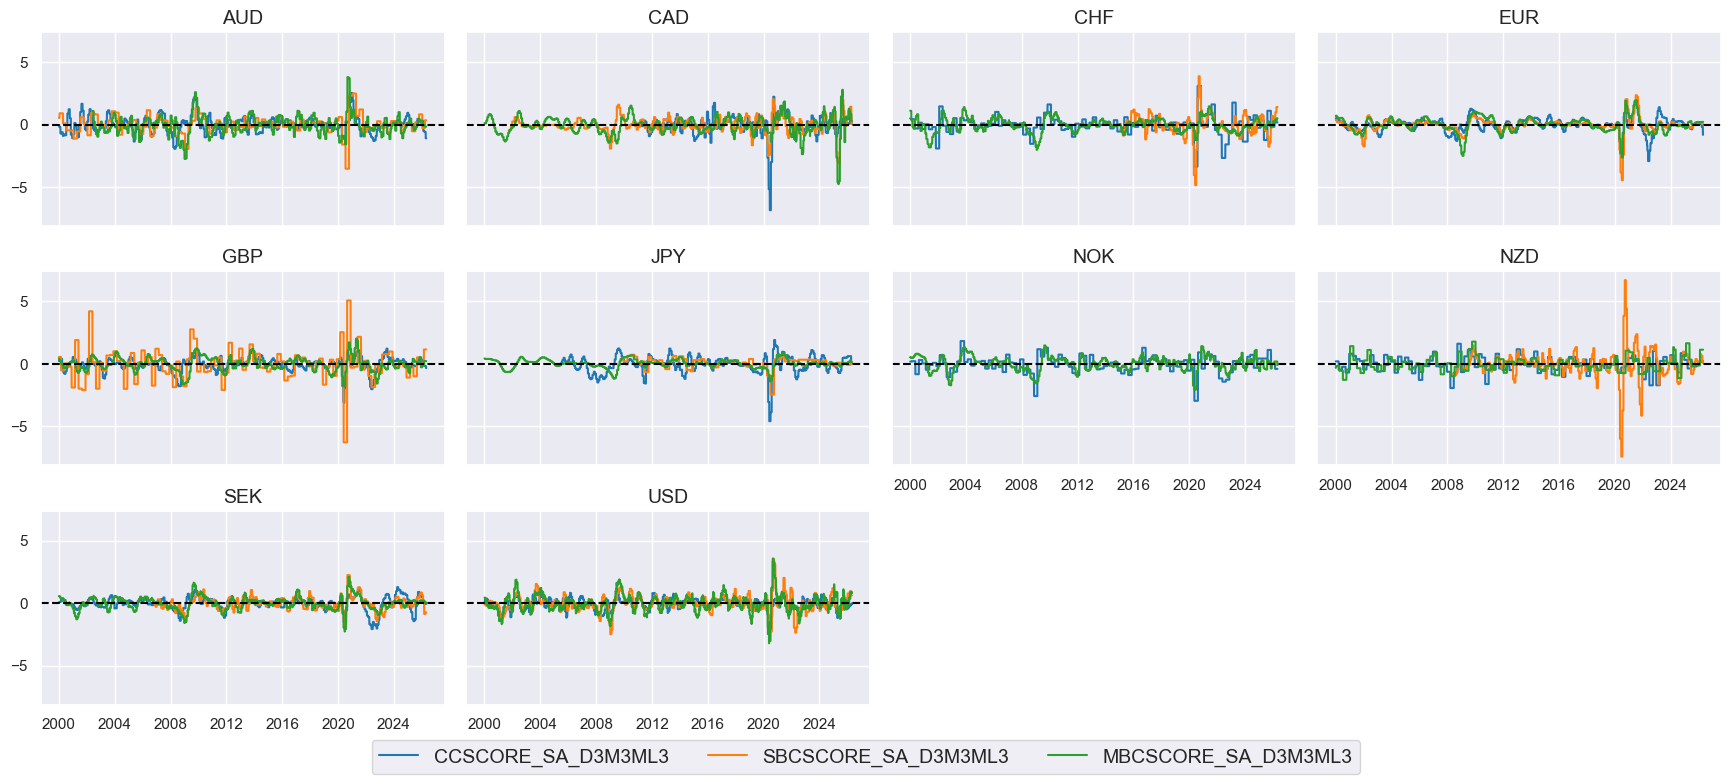

In [49]:
# Confidence changes constituents visualization

confchanges = [s for s in surveys if s.endswith("D3M3ML3")]

xcatx = confchanges
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [50]:
# Confidence changes constituents scoring

xcatx = confchanges
cidx = cids_dm

for xc in xcatx:
    dfa = msp.make_zn_scores(
        dfx,
        xcat=xc,
        cids=cidx,
        sequential=True,
        min_obs=522,  # oos scaling after 2 years of panel data
        est_freq="m",
        neutral="zero",
        pan_weight=1,
        thresh=3,
        postfix="_ZN",
    )
    dfx = msm.update_df(dfx, dfa, xcat_replace=True)

confchangez = [xc + "_ZN" for xc in confchanges]

In [51]:
# Confidence changes combined factor score

xcatx = confchangez
cidx = cids_dm

# Linear combination of whatever is available

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="CONFCHANGE",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-scoring of composite factor

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

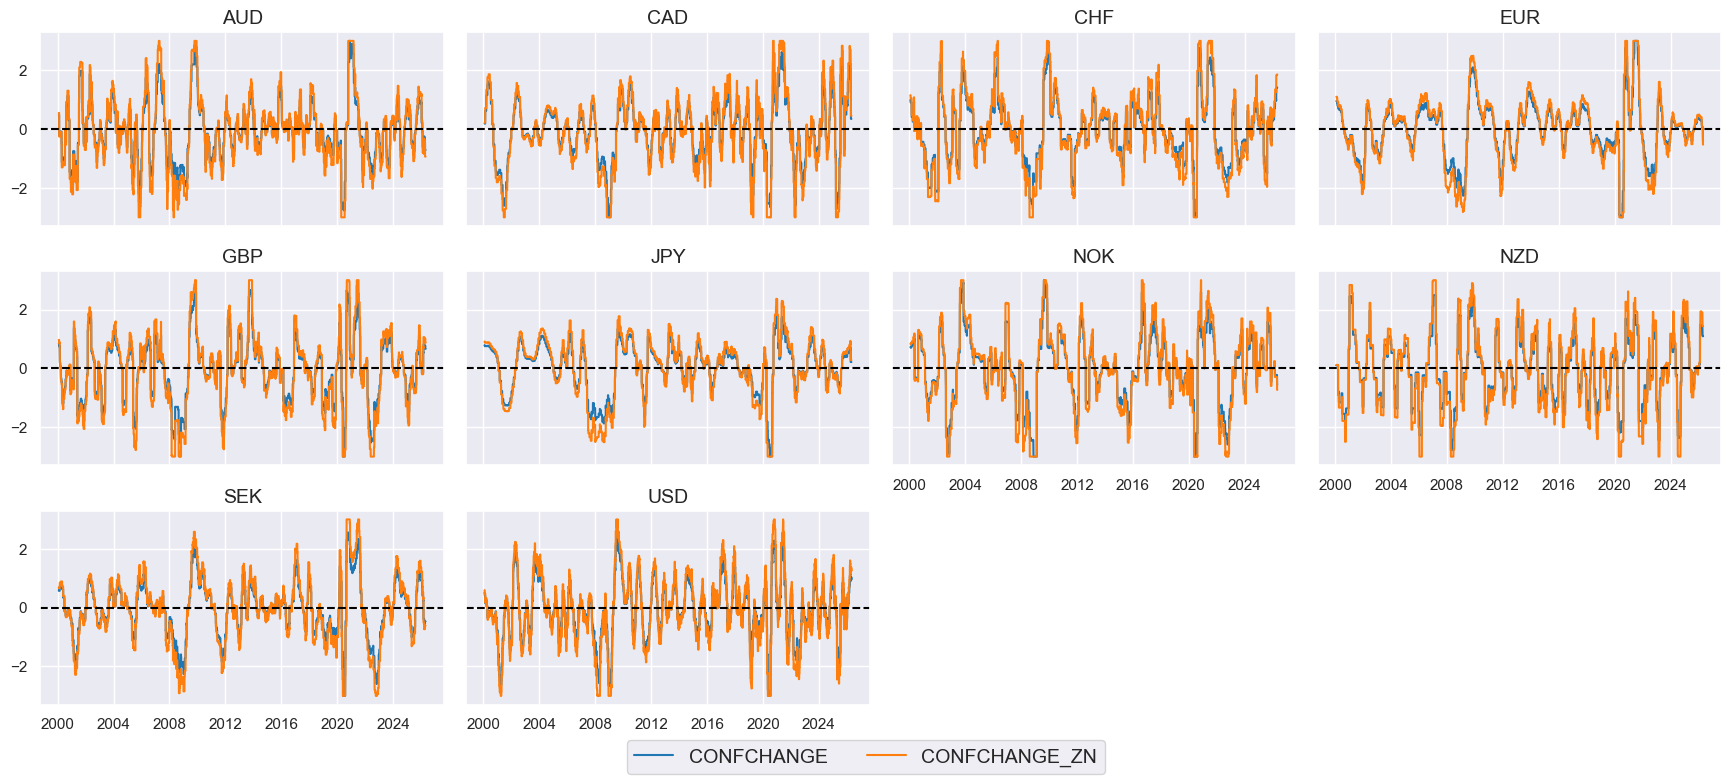

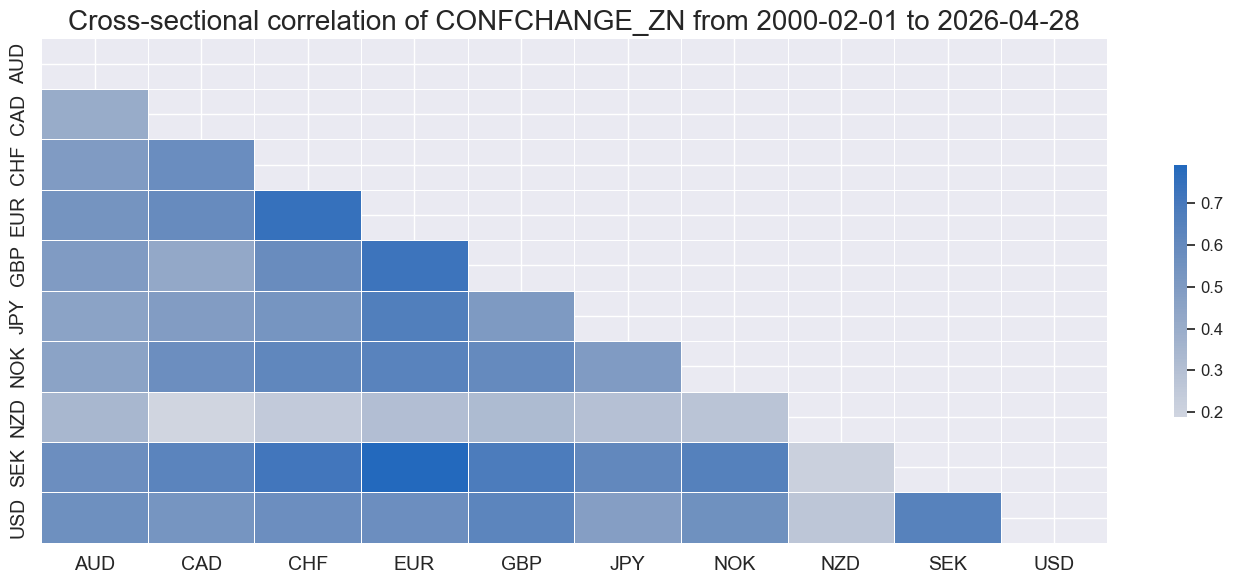

In [52]:
# Confidence changes factor visualization

xcatx = ["CONFCHANGE", "CONFCHANGE_ZN"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Quantitative easing

In [53]:
# QE constituents calculations

cbal = "INTLIQGDP_NSA"
calcs = [
    f"{cbal}_D1M1ML6AR = {cbal}_D1M1ML6 * 2 ** 0.5",
    f"{cbal}_D1M1ML3AR = {cbal}_D1M1ML3 * 4 ** 0.5",
    f"{cbal}_D1M1ML1AR = {cbal}_D1M1ML1 * 12 ** 0.5",
]
dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cids)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

qes = list(dfa["xcat"].unique())

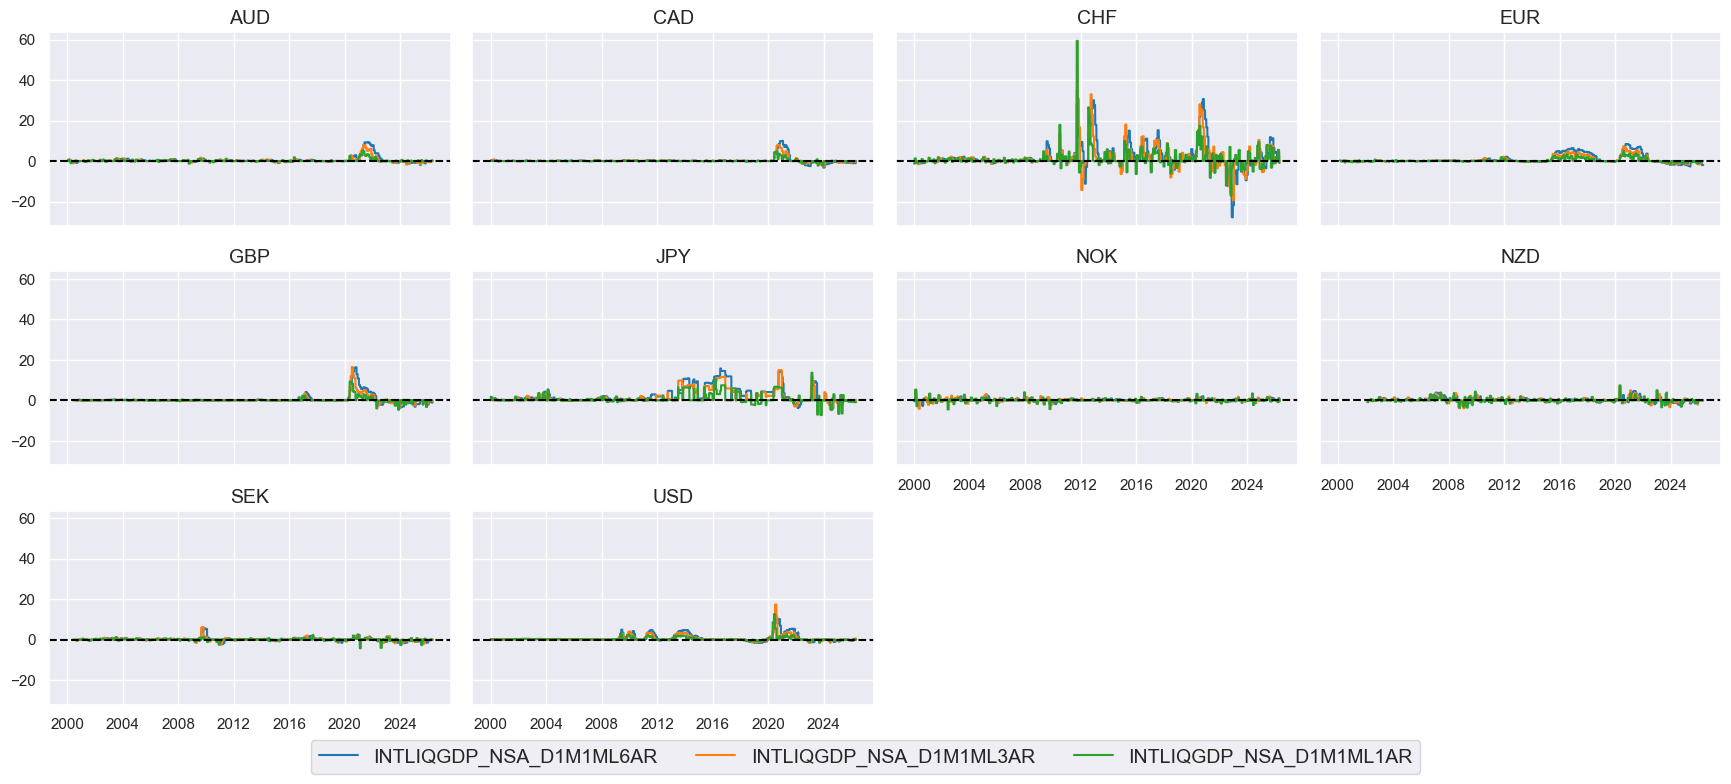

In [54]:
# QE constituents visualization

xcatx = qes
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [55]:
# QE constituents scoring

xcatx = qes
cidx = cids_dm

for xc in xcatx:
    dfa = msp.make_zn_scores(
        dfx,
        xcat=xc,
        cids=cidx,
        sequential=True,
        min_obs=522,  # oos scaling after 2 years of panel data
        est_freq="m",
        neutral="zero",
        pan_weight=1,
        thresh=3,
        postfix="_ZN",
    )
    dfx = msm.update_df(dfx, dfa, xcat_replace=True)

qez = [xc + "_ZN" for xc in qes]

In [56]:
# QE combined factor score

xcatx = qez
cidx = cids_dm

# Linear combination of whatever is available

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="QUANTEASE",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-scoring of composite factor

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

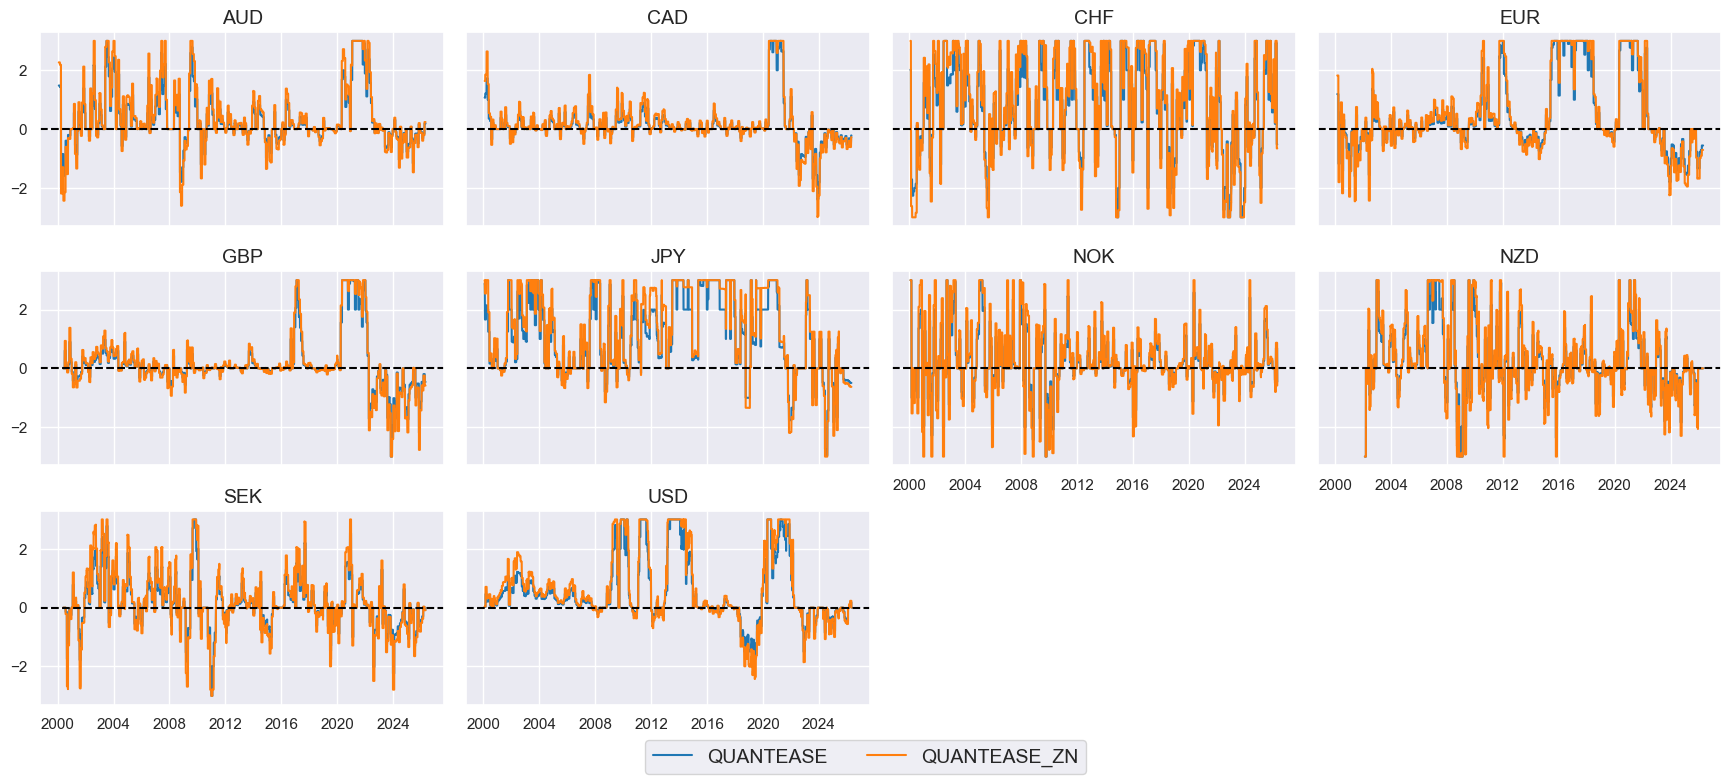

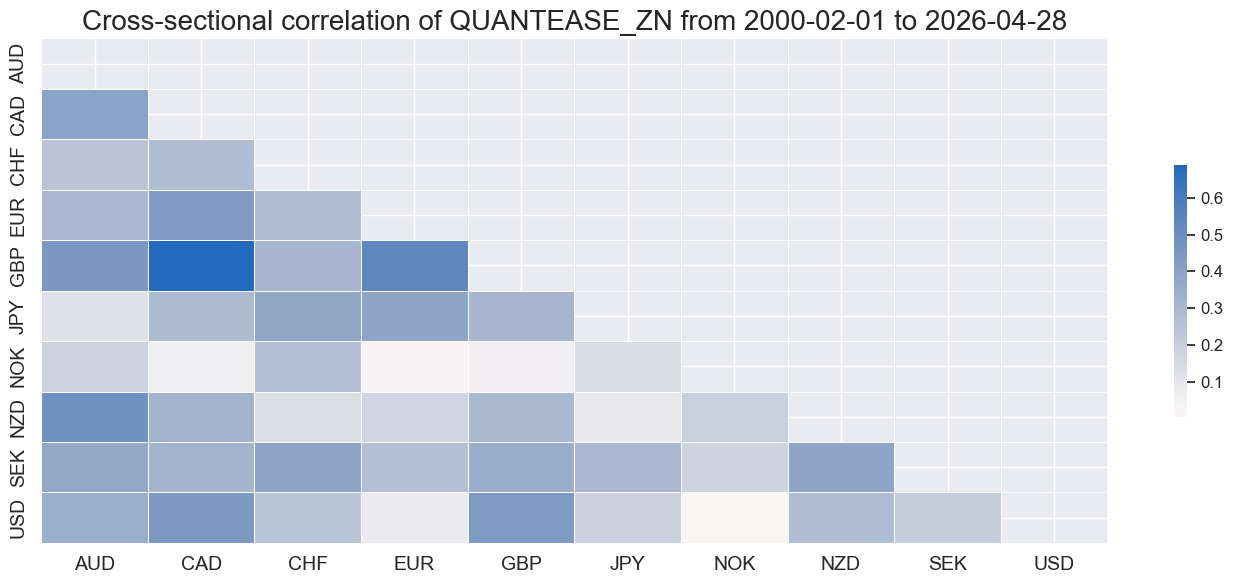

In [57]:
# QE factor visualization

xcatx = ["QUANTEASE", "QUANTEASE_ZN"]
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Real yield differentials

In [58]:
# Real differentials constituents calculations

calcs = [
    "DU02YRYLD = DU02YYLD_NSA - INFE2Y_JA ",
    "DU10YRYLD = DU10YYLD_NSA - 0.5 * ( INFE5Y_JA + INFTEFF_NSA )",
    "XDU10v2RYLD = DU10YRYLD - DU02YRYLD - 1",
]
dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cids)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

realdiffs = [xc for xc in list(dfa["xcat"].unique()) if "v2RYLD" in xc]

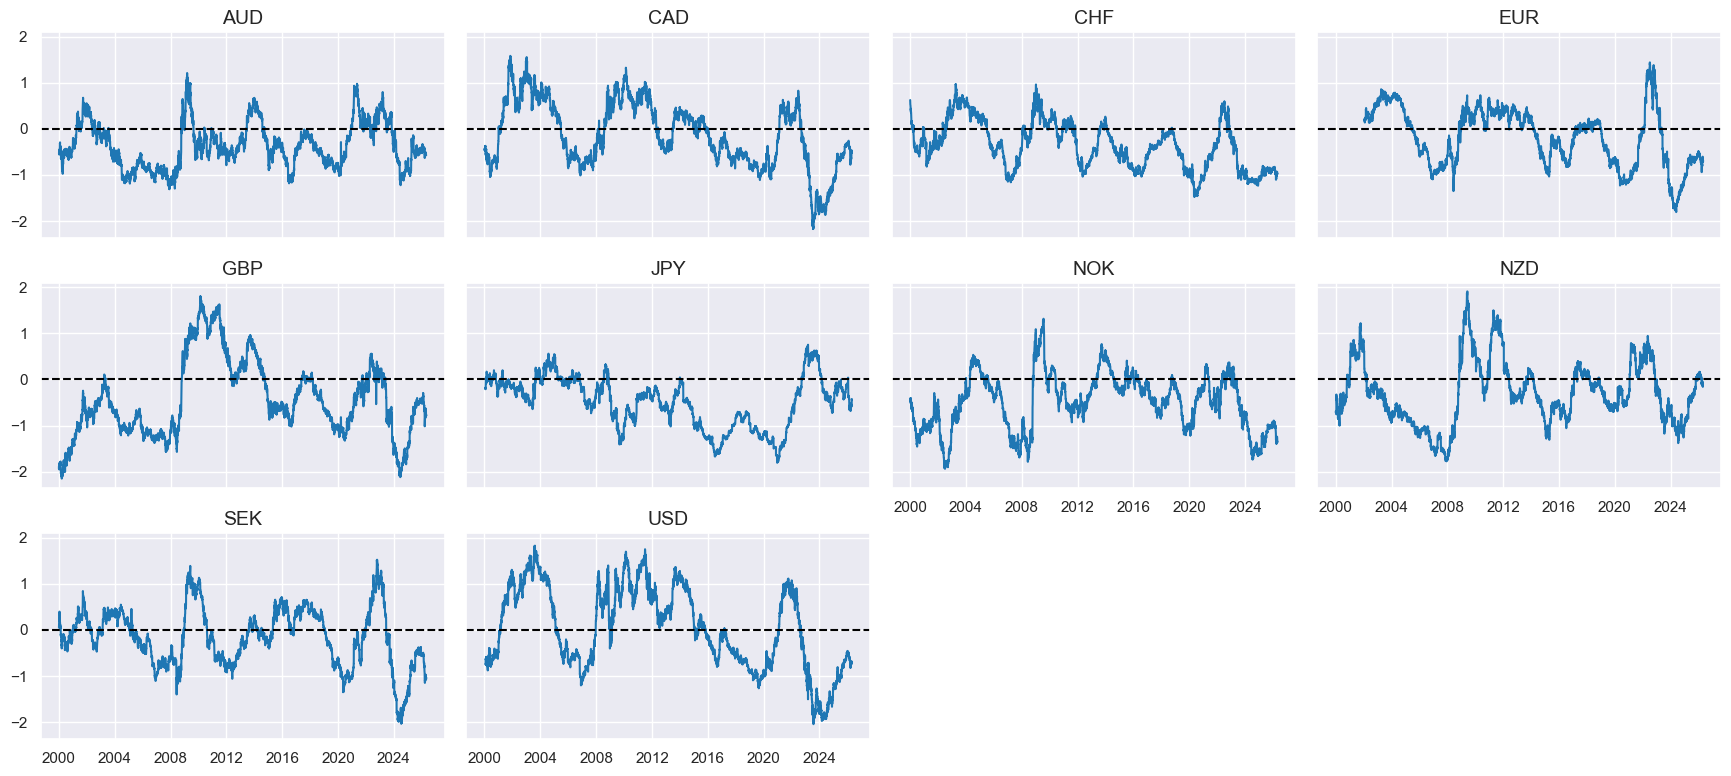

In [59]:
# Real differentials visualization

xcatx = realdiffs
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

In [60]:
# Real differentials scoring

xcatx = realdiffs
cidx = cids_dm

for xc in xcatx:
    dfa = msp.make_zn_scores(
        dfx,
        xcat=xc,
        cids=cidx,
        sequential=True,
        min_obs=522,  # oos scaling after 2 years of panel data
        est_freq="m",
        neutral="zero",
        pan_weight=1,
        thresh=3,
        postfix="_ZN",
    )
    dfx = msm.update_df(dfx, dfa, xcat_replace=True)

realdiffz = [xc + "_ZN" for xc in realdiffs]

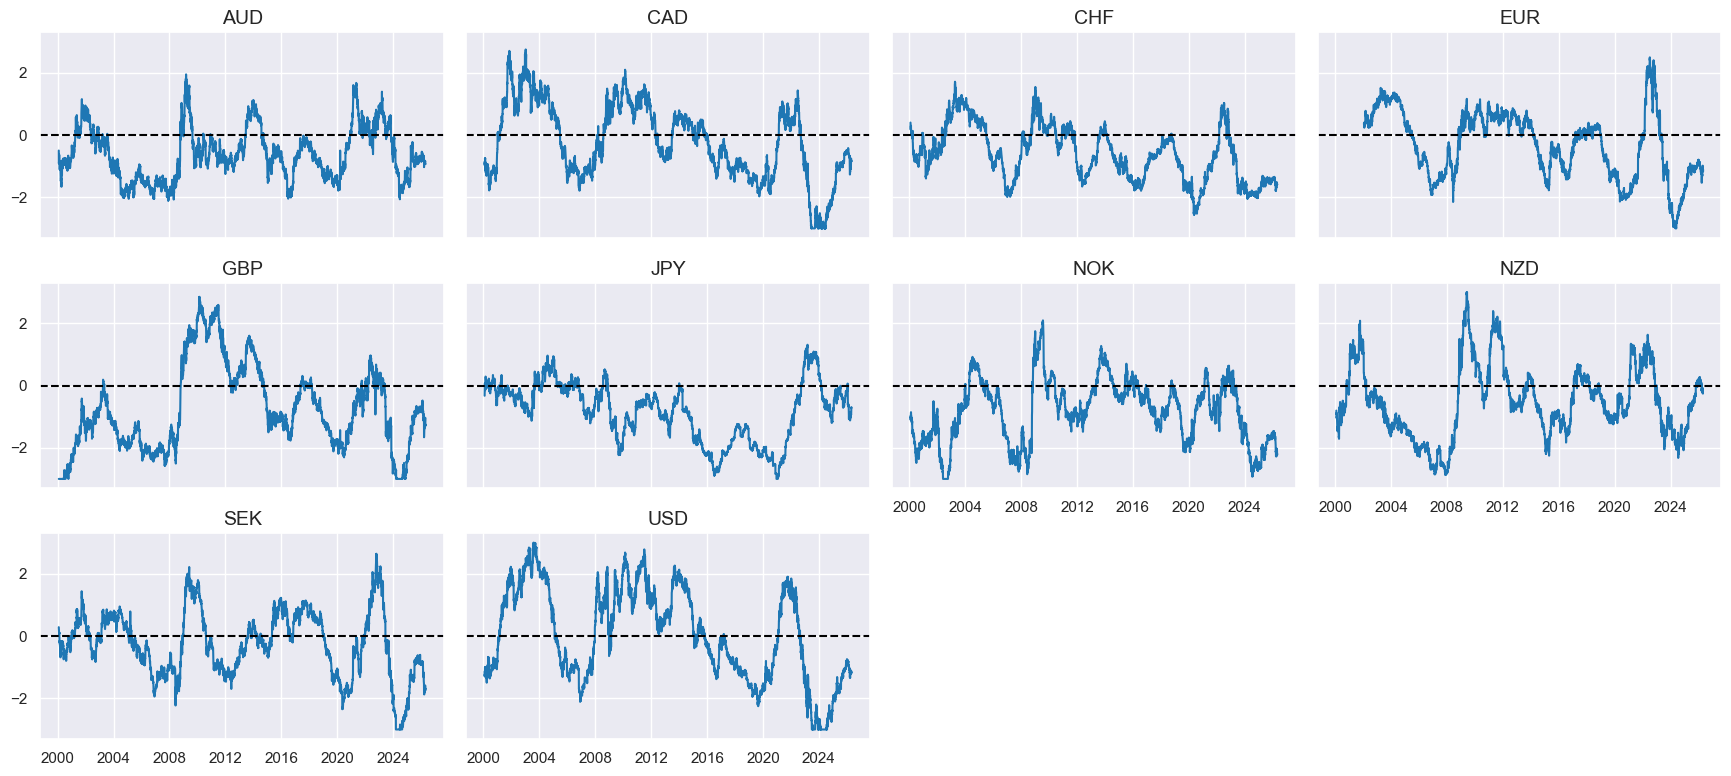

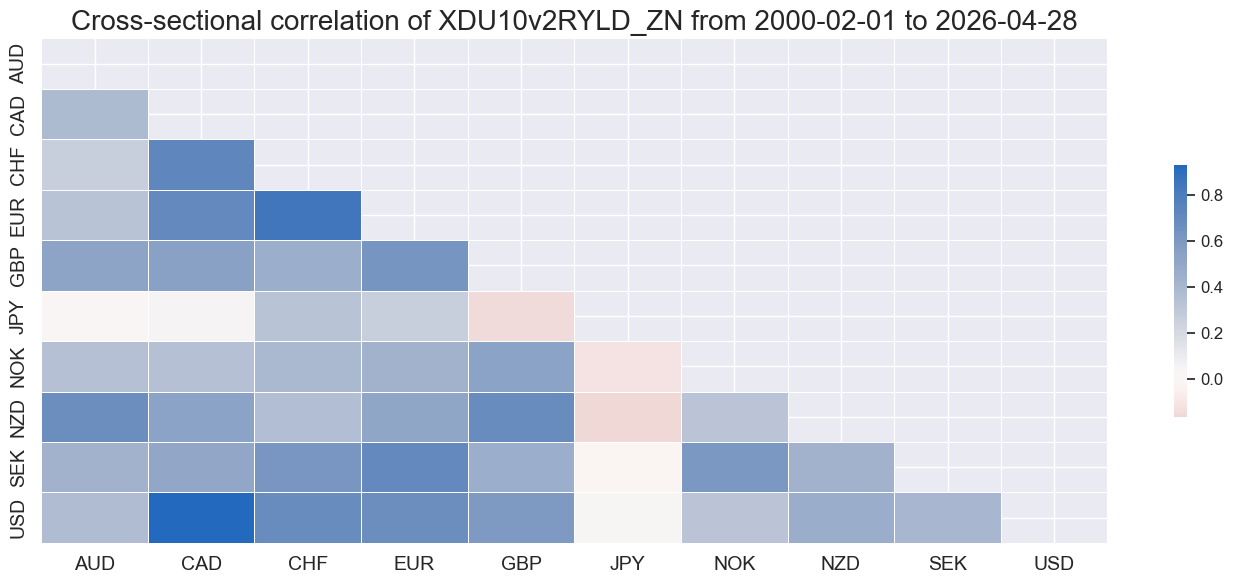

In [61]:
# Real differentials scores visualization

xcatx = realdiffz
cidx = cids_dm


msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title=None,
    title_fontsize=20,
    height=1.8,
    legend_fontsize=14,
    xcat_labels=None,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[0],
    cids=cidx,
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    size=(14, 6),
)

### Factor analysis

In [62]:
# Factor scores list

factor_labels = {
    "LABTIGHT_ZN": "Labor market tightness",
    "XINF_ZN": "Inflation pressure",
    "XFIN_ZN": "Financial conditions",
    "OVERHEAT_ZN": "Economic overheating",
    "DEBTIMPROVE_ZN": "Debt sustainability improvement",
    "CONFLEVEL_ZN": "Confidence level",
    "CONFCHANGE_ZN": "Change in confidence",
    "QUANTEASE_ZN": "Quantitative easing stance",
    "XDU10v2RYLD_ZN": "10s-2s real yield differential",
}

factorz = list(factor_labels.keys())

# Excluding real differentials

xfactorz = [factor for factor in factorz if not "v2RYLD" in factor]

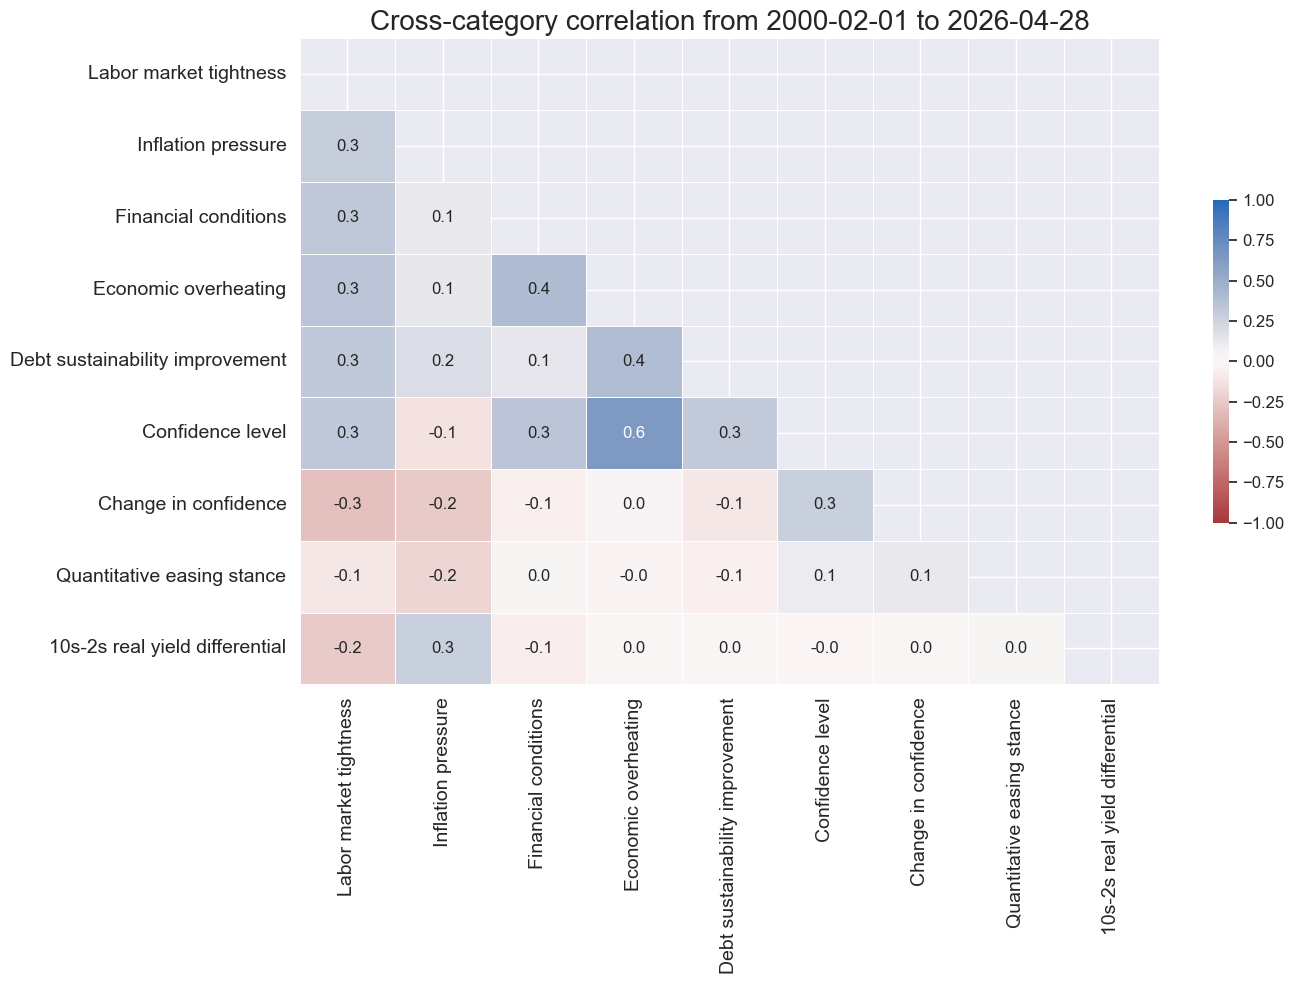

In [63]:
# Cross-correlation

cidx = cids_dm
xcatx = factorz
start = "2000-01-01"

msp.correl_matrix(
    dfx,
    cids=cidx,
    xcats=xcatx,
    max_color=1.0,
    annot=True, 
    fmt=".1f",
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    xcat_labels=factor_labels,
    start=start,
    size=(14, 10)
)

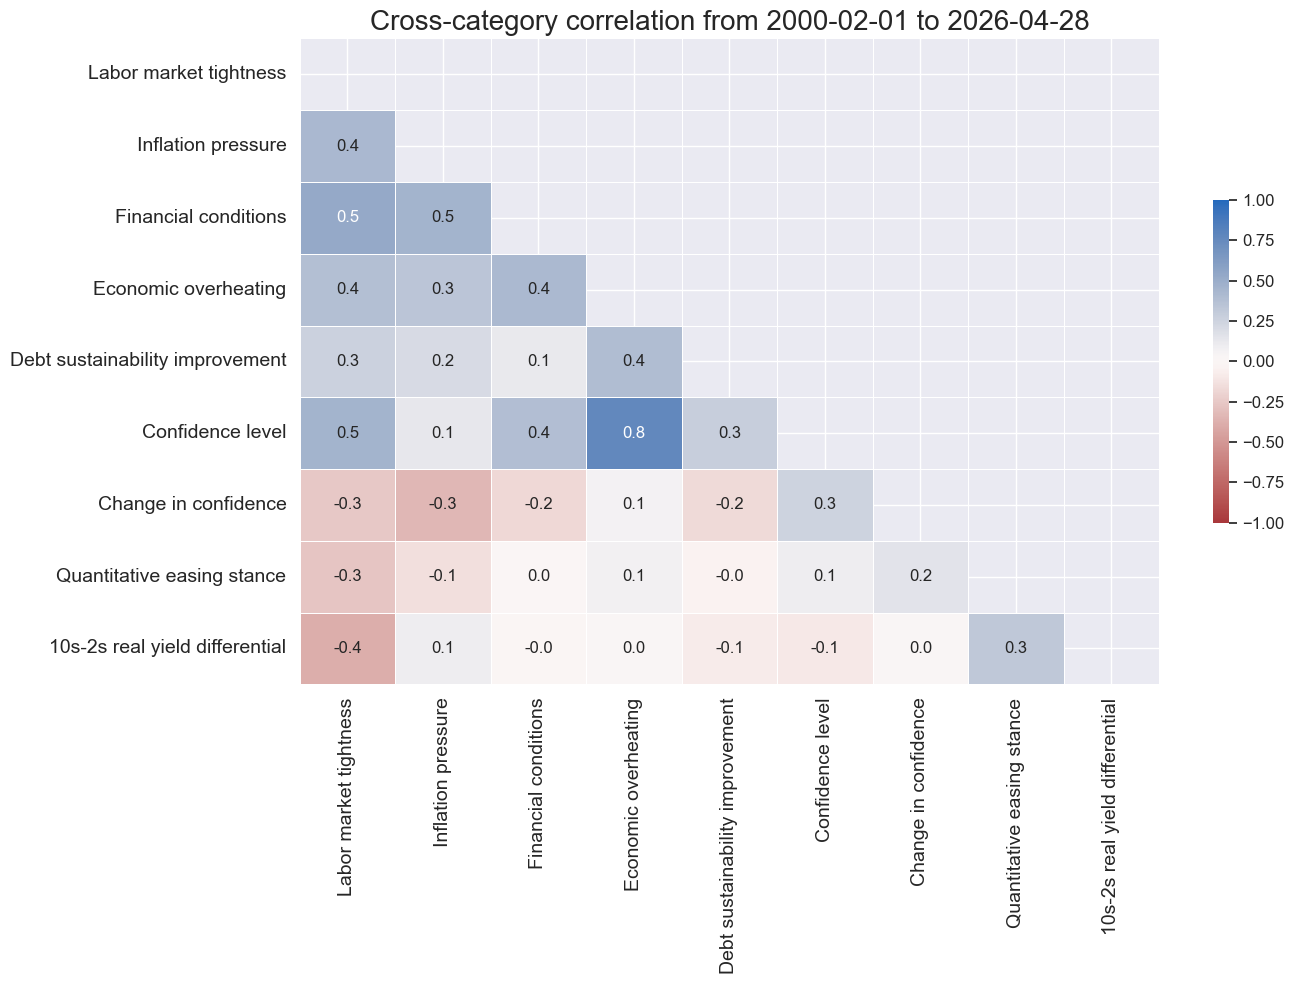

In [64]:
# Cross-correlation for G2 only

cidx = cids_dm
xcatx = factorz
start = "2000-01-01"

msp.correl_matrix(
    dfx,
    cids=["EUR", "USD"],
    xcats=xcatx,
    max_color=1.0,
    annot=True, 
    fmt=".1f",
    freq="M",
    cluster=False,
    title=None,
    title_fontsize=20,
    xcat_labels=factor_labels,
    start=start,
    size=(14, 10)
)

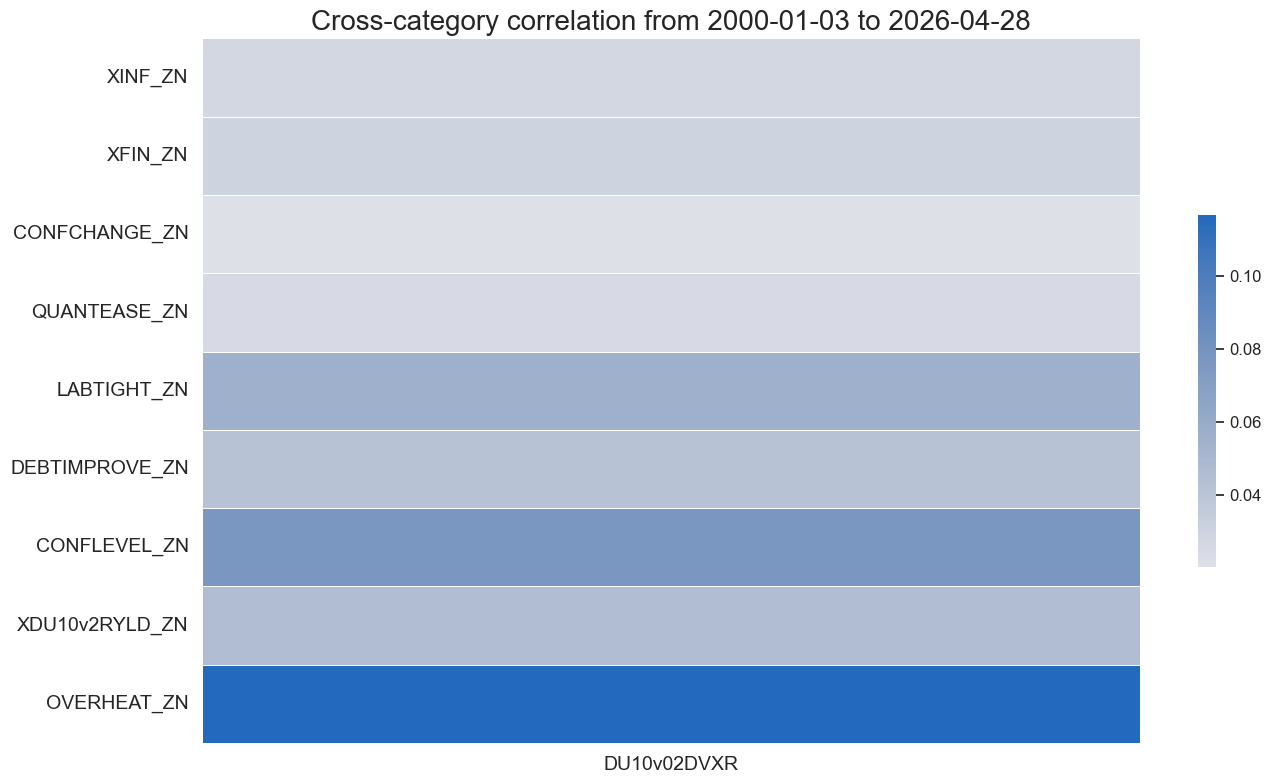

In [65]:
feats = factorz
rets = ["DU10v02DVXR"]
lag_dict = {feat: 1 for feat in feats}


msp.correl_matrix(
    dfx,
    xcats=rets,
    xcats_secondary=feats, 
    cids=cids_dm,
    freq="M",
    start="2000-01-01",
    lags_secondary=lag_dict,
    # max_color=0.4,
    cluster=True, 
    title_fontsize=20
)

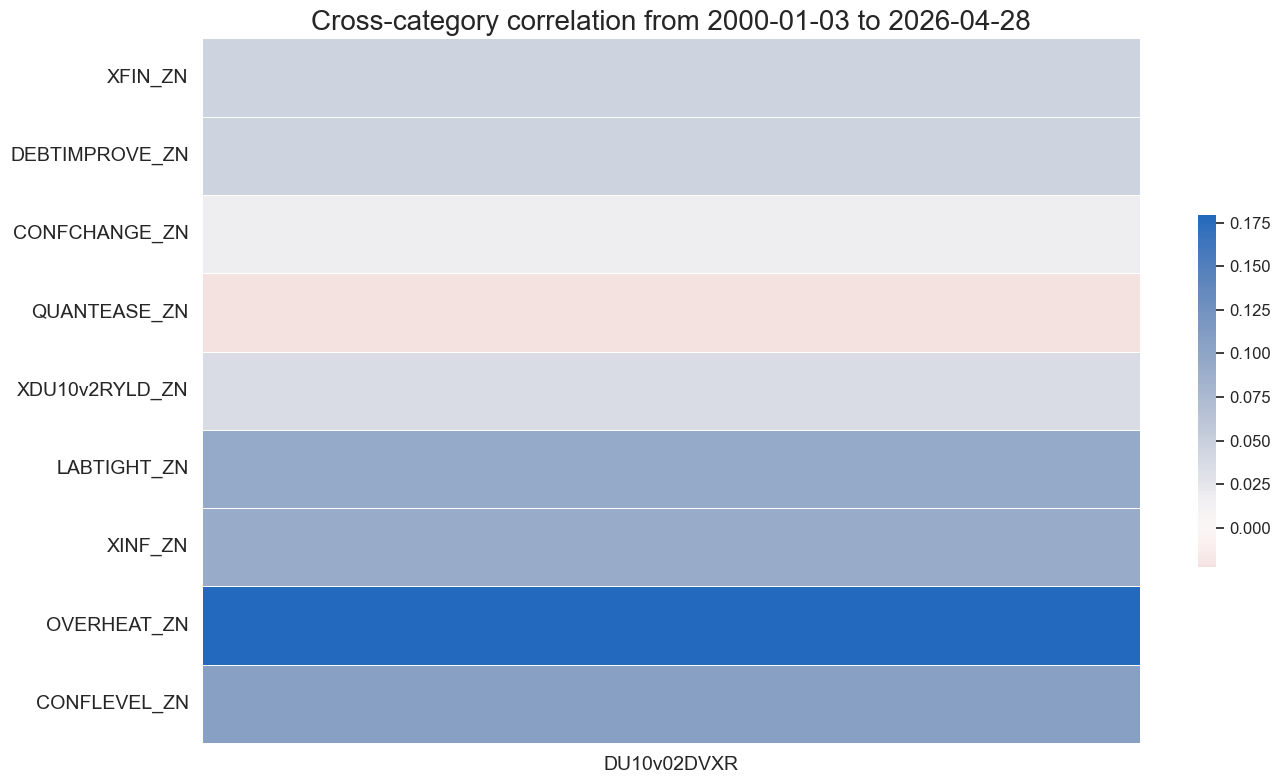

In [66]:
feats = factorz
rets = ["DU10v02DVXR"]
lag_dict = {feat: 1 for feat in feats}


msp.correl_matrix(
    dfx,
    xcats=rets,
    xcats_secondary=feats, 
    cids=["EUR", "USD"],
    freq="M",
    start="2000-01-01",
    lags_secondary=lag_dict,
    # max_color=0.4,
    cluster=True, 
    title_fontsize=20
)

### Hybrid factors

In [67]:
# Hybrid factor calculations

cidx = cids_xg2
xcatx = factorz

calcs = [f"{x}H = 0.5 * {x} + 0.25 * ( iUSD_{x} + iEUR_{x} )" for x in xcatx]
dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cidx)
dfx = msm.update_df(dfx, dfa)

# Pseudo hybrid factor calculations

cidx = cids_g2
xcatx = factorz

calcs = [f"{x}H = {x} " for x in xcatx]
dfa = msp.panel_calculator(dfx, calcs=calcs, cids=cidx)
dfx = msm.update_df(dfx, dfa)

factorzh = [x + "H" for x in factorz]
xfactorzh = [x + "H" for x in xfactorz]

hybrid_labels = {x + "H": label + " (hybrid)" for x, label in factor_labels.items()}

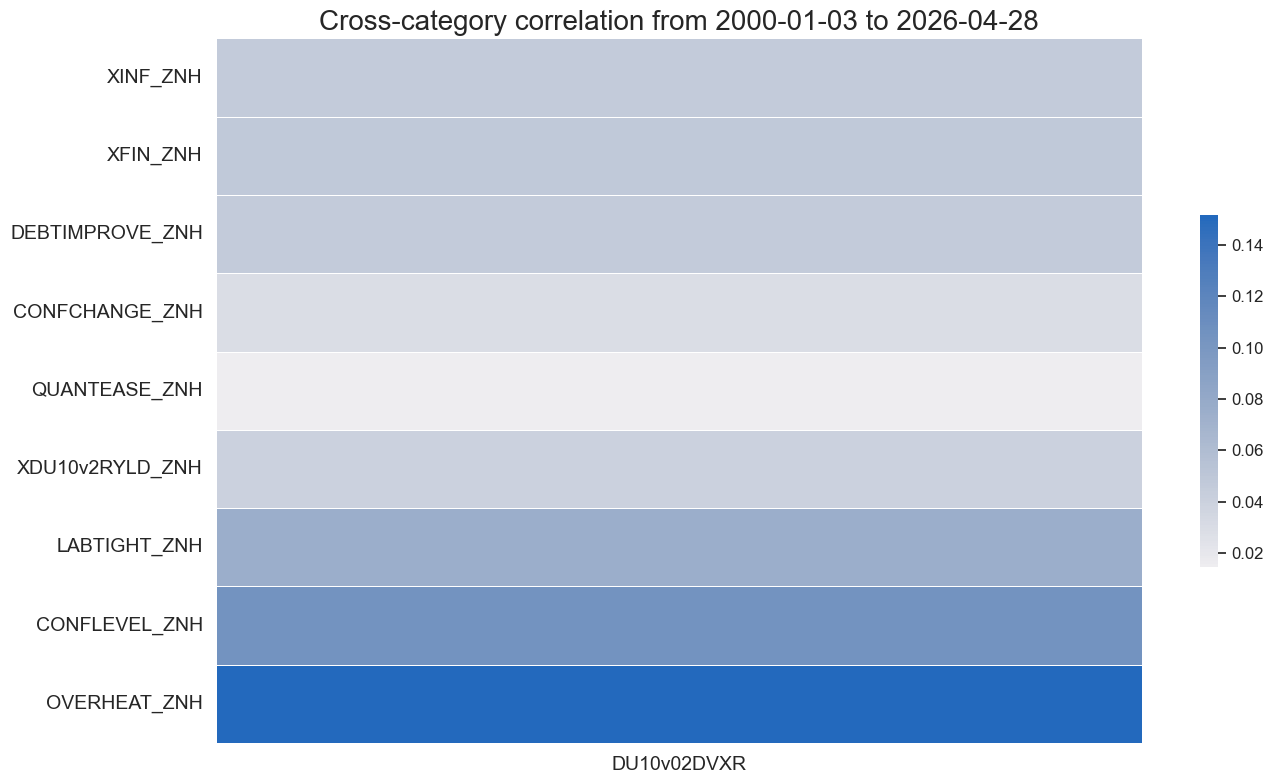

In [68]:
feats = factorzh
rets = ["DU10v02DVXR"]
lag_dict = {feat: 1 for feat in feats}


msp.correl_matrix(
    dfx,
    xcats=rets,
    xcats_secondary=feats, 
    cids=cids_dm,
    freq="M",
    start="2000-01-01",
    lags_secondary=lag_dict,
    # max_color=0.4,
    cluster=True, 
    title_fontsize=20
)

## Signals

### Conceptual parity

In [69]:
# Simple conceptual parity

xcatx = factorz
cidx = cids_dm

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="CP",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

In [70]:
# Balanced conceptual parity

# Score excluding real yield differentials

xcatx = xfactorz
cidx = cids_dm

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="XCP",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-score

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Balanced conceptual parity score

xcatx = ["XCP_ZN", "XDU10v2RYLD_ZN"]
cidx = cids_dm

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="BCP",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

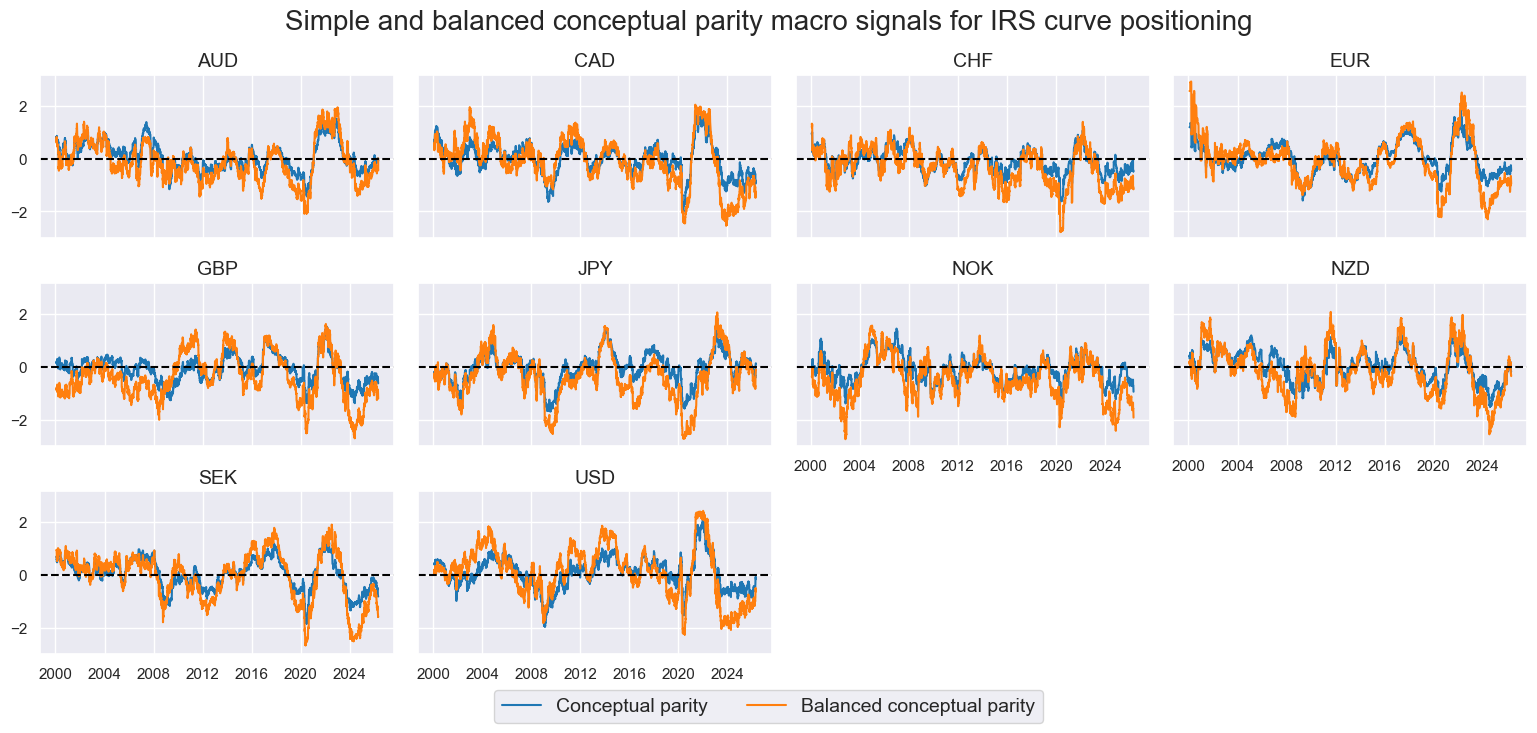

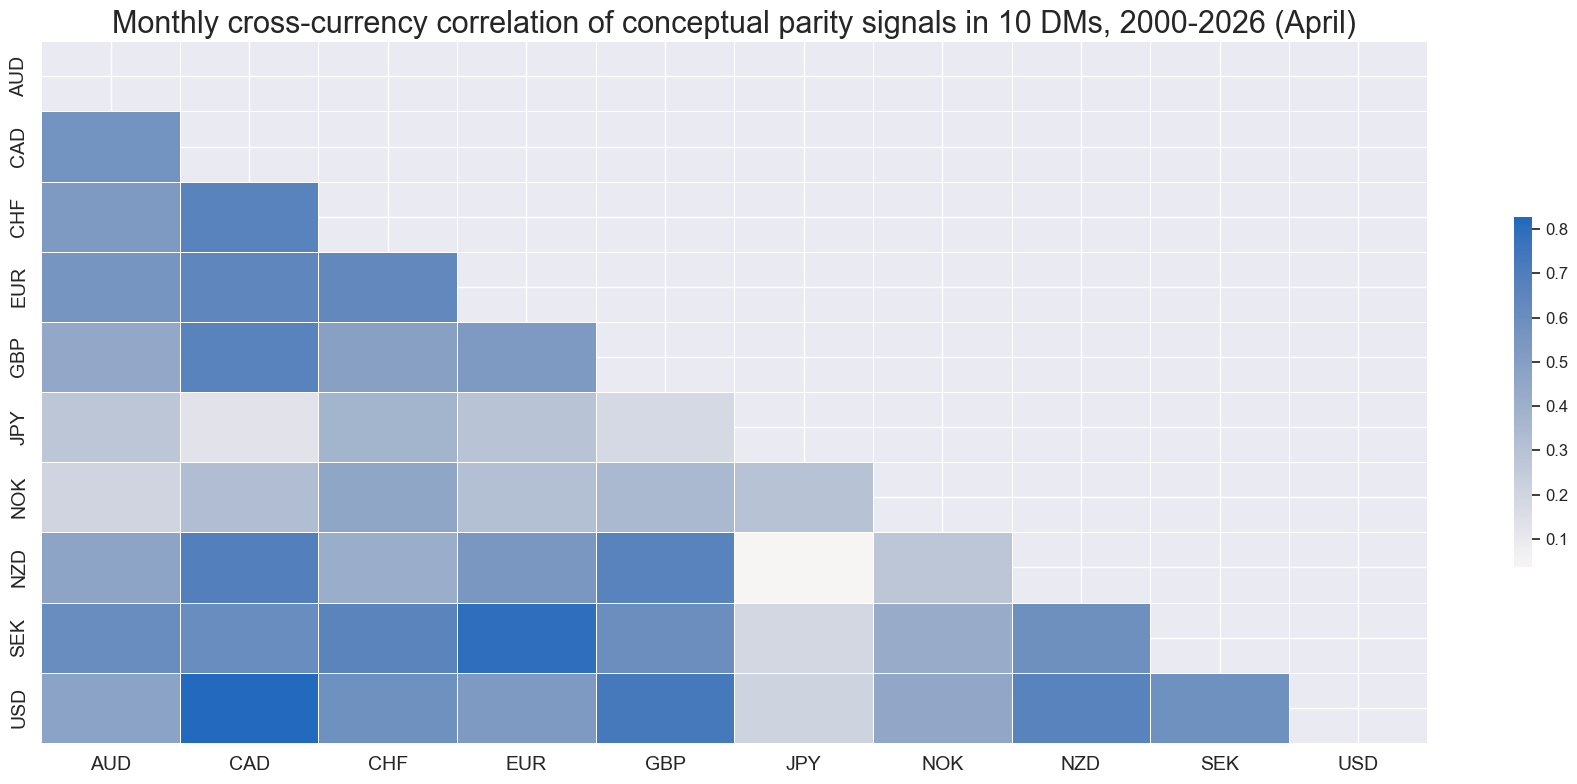

In [71]:
# Conceptual parity factor visualization

xcatx = ["CP", "BCP"]
cidx = cids_dm

sig_labels = {"CP": "Conceptual parity", "BCP": "Balanced conceptual parity"}

msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title="Simple and balanced conceptual parity macro signals for IRS curve positioning",
    title_fontsize=20,
    height=1.6,
    legend_fontsize=14,
    xcat_labels=sig_labels,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title="Monthly cross-currency correlation of conceptual parity signals in 10 DMs, 2000-2026 (April)",
    title_fontsize=22,
    size=(18, 8),
)

### Hybrid conceptual parity

In [72]:
# Simple hybrid conceptual parity

xcatx = factorzh
cidx = cids_dm

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="CPH",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

In [73]:
# Balanced hybrid conceptual parity

# Score excluding real yield differentials

xcatx = xfactorzh
cidx = cids_dm

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="XCPH",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Re-score

xc = dfa["xcat"].iloc[0]

dfa = msp.make_zn_scores(
    dfx,
    xcat=xc,
    cids=cidx,
    sequential=True,
    min_obs=522,  # oos scaling after 2 years of panel data
    est_freq="m",
    neutral="zero",
    pan_weight=1,
    thresh=3,
    postfix="_ZN",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

# Balanced conceptual parity score
xcatx = ["XCPH_ZN", "XDU10v2RYLD_ZN"]
cidx = cids_dm

dfa = msp.linear_composite(
    dfx,
    xcats=xcatx,
    cids=cidx,
    complete_xcats=False,  # if some categories are missing the score is based on the remaining
    new_xcat="BCPH",
)
dfx = msm.update_df(dfx, dfa, xcat_replace=True)

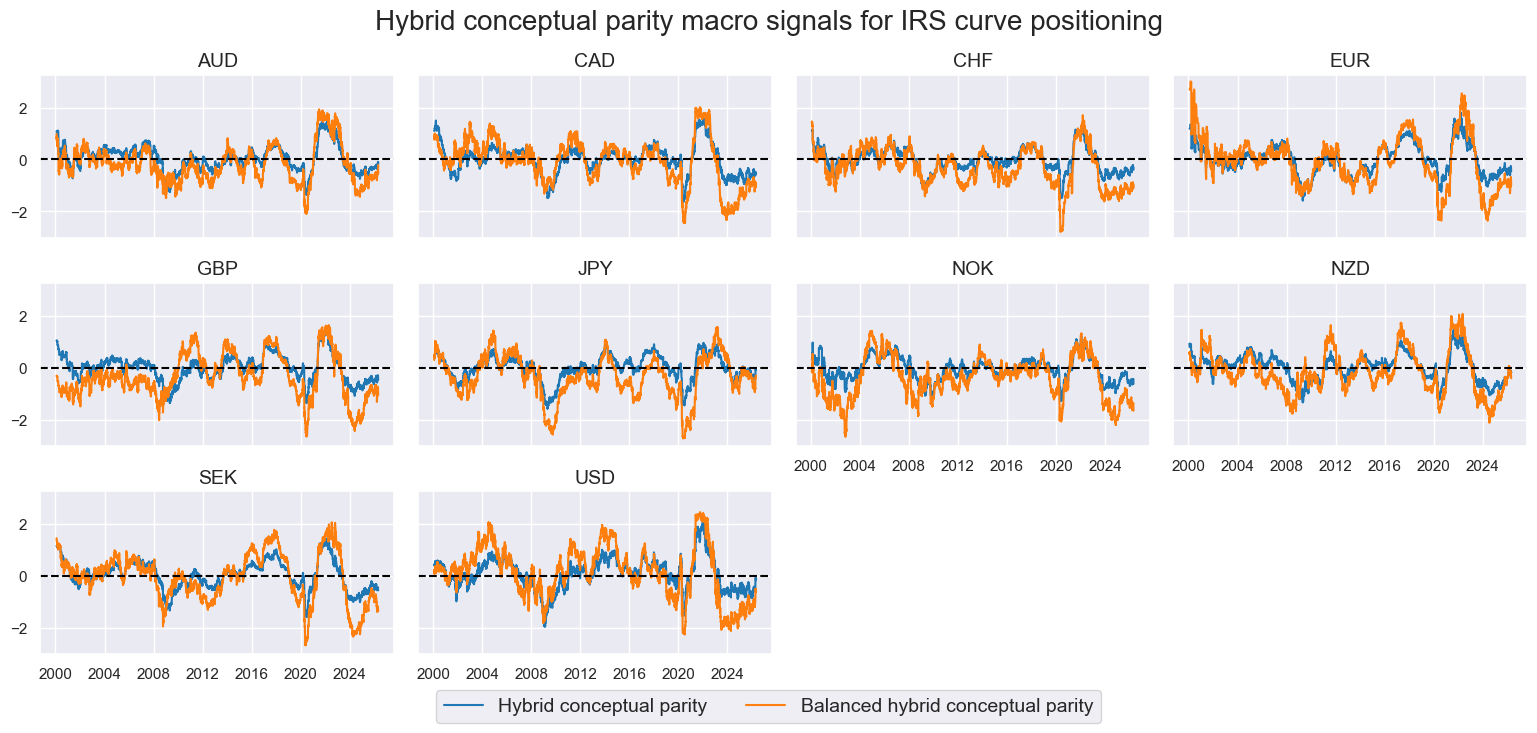

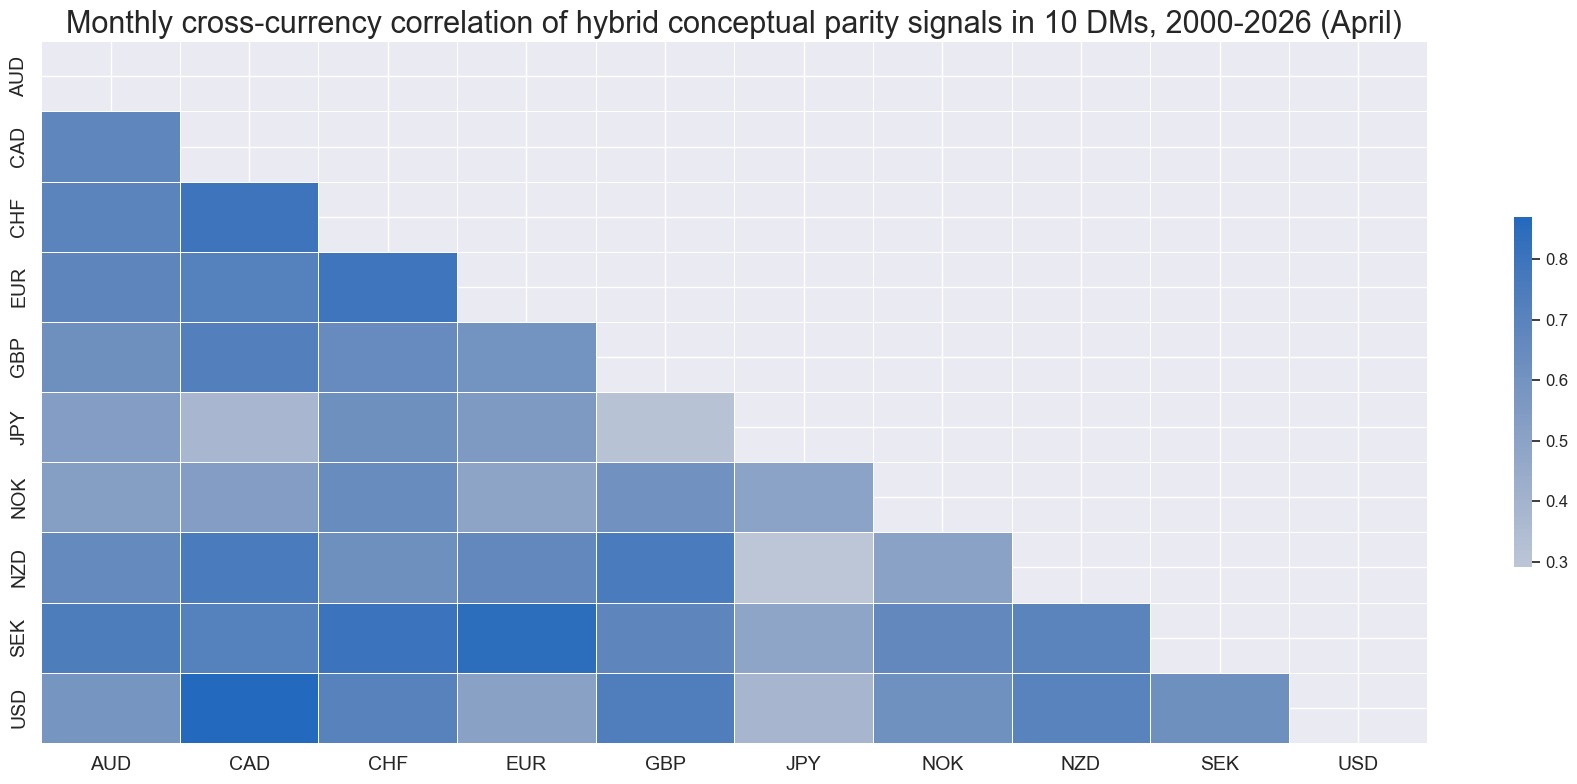

In [74]:
# Conceptual parity factor visualization

xcatx = ["CPH", "BCPH"]
cidx = cids_dm

sig_labels = {
    "CPH": "Hybrid conceptual parity",
    "BCPH": "Balanced hybrid conceptual parity",
}

msp.view_timelines(
    dfx,
    xcats=xcatx,
    cids=cidx,
    ncol=4,
    same_y=True,
    title="Hybrid conceptual parity macro signals for IRS curve positioning",
    title_fontsize=20,
    height=1.6,
    legend_fontsize=14,
    xcat_labels=sig_labels,
    cid_labels=None,
)

msp.correl_matrix(
    dfx,
    xcats=xcatx[1],
    cids=cidx,
    freq="M",
    cluster=False,
    title="Monthly cross-currency correlation of hybrid conceptual parity signals in 10 DMs, 2000-2026 (April)",
    title_fontsize=22,
    size=(18, 8),
)

## Value checks

### Specs and panel test

In [75]:
# Parity specs

dict_cps = {
    "sigx": ["CP", "BCP", "CPH", "BCPH"],
    "targx": ["DU10v02DVXR"],
    "cidx": cids_dm,
    "start": "2000-01-01",
    "crs": None,
    "srr": None,
    "pnls": None,
}

In [76]:
# Parity panel regression

dix = dict_cps

sigs = dix["sigx"]
targs = dix["targx"]
cidx = dix["cidx"]
start = dix["start"]

# Initialize the dictionary to store CategoryRelations instances

dict_cr = {}

for targ in targs:
    for sig in sigs:
        lab = sig + "_" + targ
        dict_cr[lab] = msp.CategoryRelations(
            dfx,
            xcats=[sig, targ],
            cids=cidx,
            freq="M",
            lag=1,
            xcat_aggs=["last", "sum"],
            start=start,
            xcat_trims=(100, 100) # remove single dubious outlier
        )

dix["crs"] = dict_cr

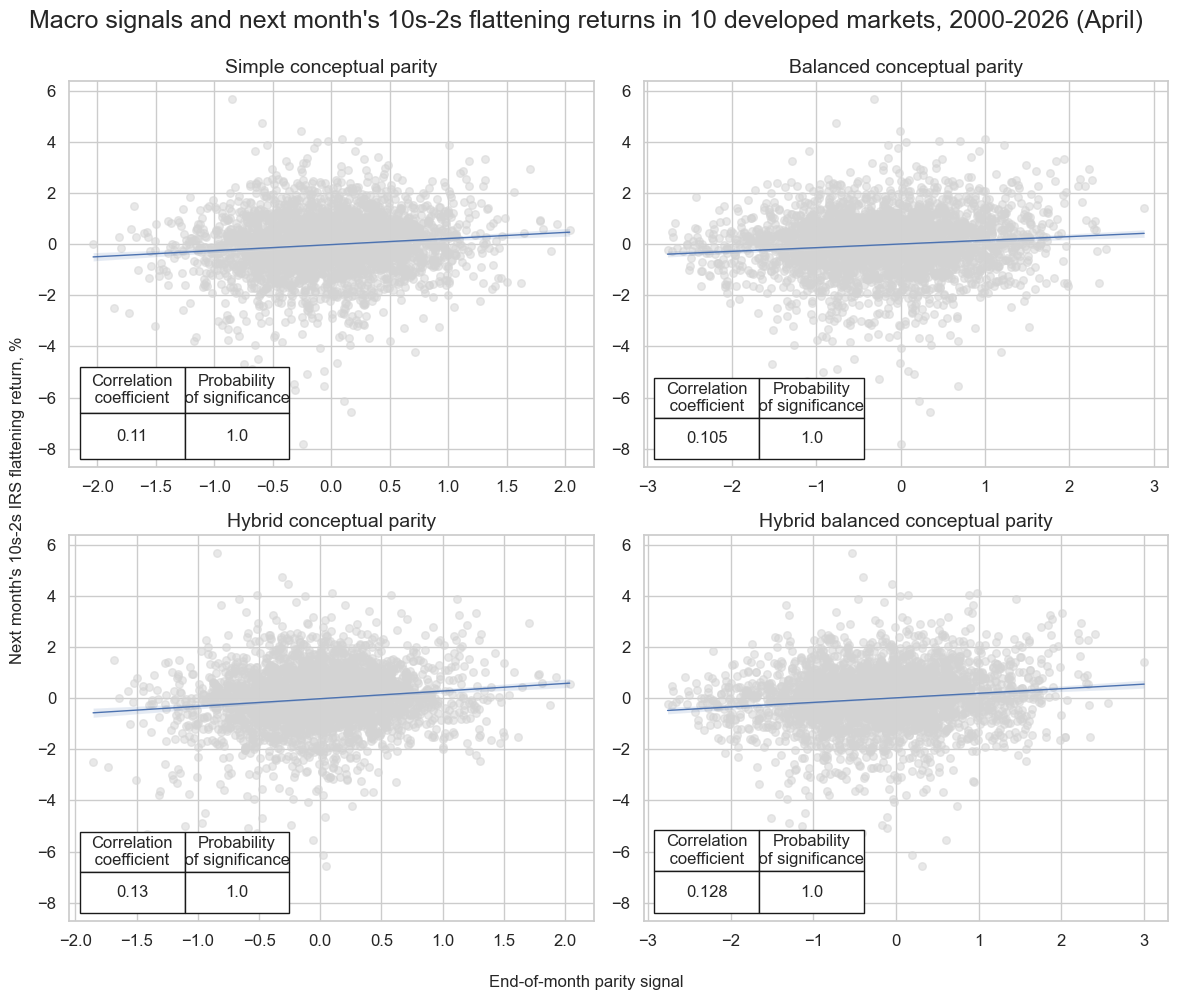

In [ ]:
# Parity panel plots

dix = dict_cps
dict_cr = dix["crs"]
sigs = dix["sigx"]
targs = dix["targx"]

scatter_labels = {
    "CP_DU10v02DVXR": "Simple conceptual parity",
    "BCP_DU10v02DVXR": "Balanced conceptual parity",
    "CPH_DU10v02DVXR": "Hybrid conceptual parity",
    "BCPH_DU10v02DVXR": "Hybrid balanced conceptual parity",
}

crs = list(dict_cr.values())
crs_keys = list(dict_cr.keys())
ncol = 2
nrow = 2

msv.multiple_reg_scatter(
    cat_rels=crs,
    ncol=ncol,
    nrow=nrow,
    figsize=(12, 10),
    prob_est="pool",
    coef_box="lower left",
    title="Macro signals and next month's 2s-10s flattening returns in 10 developed markets, 2000-2026 (April)",
    title_fontsize=18,
    subplot_titles=[scatter_labels[cr] for cr in crs_keys],
    share_axes=False,
    xlab="End-of-month parity signal",
    ylab="Next month's 2s-10s IRS flattening return, %",
    coef_box_font_size=12,
)

### Accuracy and correlation check

In [79]:
dix = dict_cps

sigs = dix["sigx"]
targs = dix["targx"]
cidx = dix["cidx"]
start = dix["start"]

srr = mss.SignalReturnRelations(
    dfx,
    cids=cidx,
    sigs=sigs,
    rets=targs,
    freqs="M",
    start=start,
)

display(srr.multiple_relations_table().round(3).transpose())

dix["srr"] = srr

Return       DU10v02DVXR                     
Signal               BCP   BCPH     CP    CPH
Frequency              M      M      M      M
Aggregation         last   last   last   last
accuracy           0.526  0.534  0.534  0.542
bal_accuracy       0.529  0.537  0.534  0.541
pos_sigr           0.420  0.415  0.487  0.522
pos_retr           0.514  0.514  0.514  0.514
pos_prec           0.547  0.557  0.549  0.553
neg_prec           0.510  0.517  0.520  0.529
pearson            0.105  0.128  0.110  0.130
pearson_pval       0.000  0.000  0.000  0.000
kendall            0.061  0.075  0.063  0.071
kendall_pval       0.000  0.000  0.000  0.000
auc                0.528  0.536  0.534  0.541

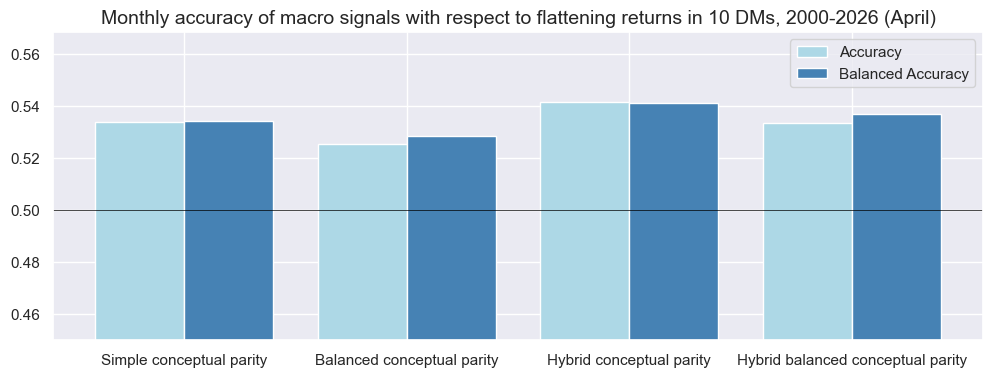

In [80]:
dix = dict_cps
srr = dix["srr"]
targ = dix["targx"][0]

sig_labels = {
    "CP": "Simple conceptual parity",
    "BCP": "Balanced conceptual parity",
    "CPH": "Hybrid conceptual parity",
    "BCPH": "Hybrid balanced conceptual parity",
}


srr.accuracy_bars(
    view="signals",
    ret=targ,
    size=(12, 4),
    title="Monthly accuracy of macro signals with respect to flattening returns in 10 DMs, 2000-2026 (April)",
    title_fontsize=14,
    x_labels=sig_labels,
    x_label_rotation=45,
)

### Naive PnL

In [81]:
# Conceptual parity PnL

dix = dict_cps

sigx = dix["sigx"]
targ = dix["targx"][0]
cidx = dix["cidx"]
start = dix["start"]

naive_pnl = msn.NaivePnL(
    dfx,
    ret=targ,
    sigs=sigx,
    cids=cidx,
    start=start,
    bms=["USD_GB05YXR_NSA", "USD_EQXR_NSA"],
)

for sig in ["CP", "BCP", "CPH", "BCPH"]:
    naive_pnl.make_pnl(
        sig,
        sig_op="zn_score_pan",
        thresh=3,
        rebal_freq="monthly",
        vol_scale=10,
        rebal_slip=1,
        pnl_name=sig + "_PZN",
    )

naive_pnl.make_long_pnl(label="Long only", vol_scale=10)

dix["pnls"] = naive_pnl

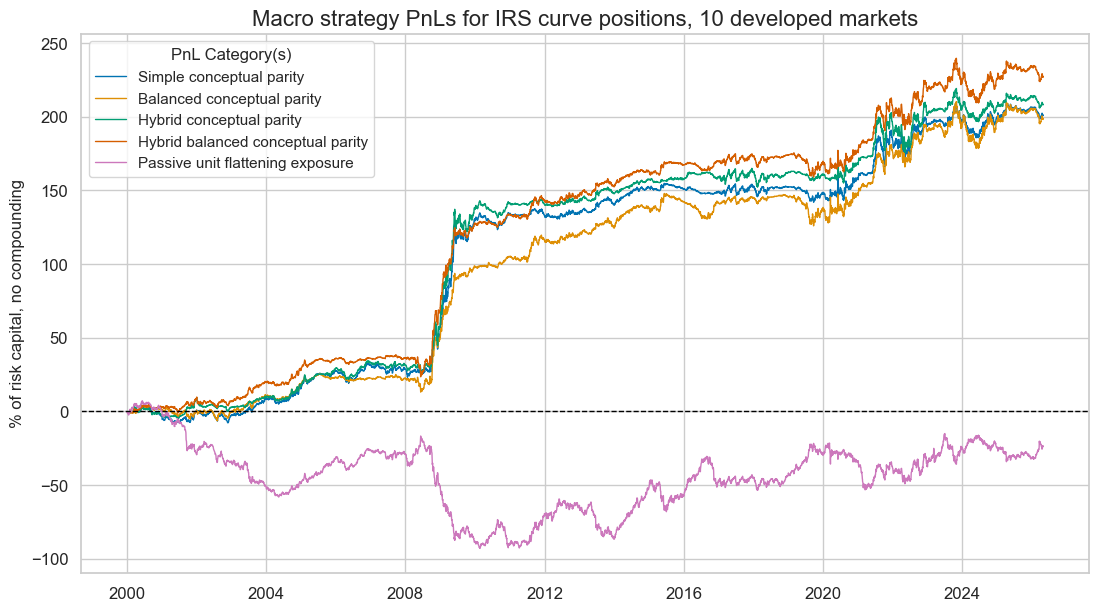

xcat,CP_PZN,BCP_PZN,CPH_PZN,BCPH_PZN,Long only
Return %,7.65681,7.556205,7.935119,8.64727,-0.885469
St. Dev. %,10.0,10.0,10.0,10.0,10.0
Sharpe Ratio,0.765681,0.75562,0.793512,0.864727,-0.088547
Sortino Ratio,1.185843,1.163431,1.226645,1.342476,-0.120172
Max 21-Day Draw %,-12.918309,-12.513149,-14.463262,-13.550129,-18.563149
Max 6-Month Draw %,-18.356789,-25.384687,-20.982373,-23.609963,-45.063624
Peak to Trough Draw %,-23.432759,-31.710659,-27.044104,-30.341714,-100.14632
Top 5% Monthly PnL Share,0.941815,0.833042,0.960982,0.806484,-5.043522
USD_GB05YXR_NSA correl,-0.053706,-0.048355,-0.012267,-0.019696,0.264291
USD_EQXR_NSA correl,0.012697,-0.008071,-0.003855,-0.019087,-0.084451


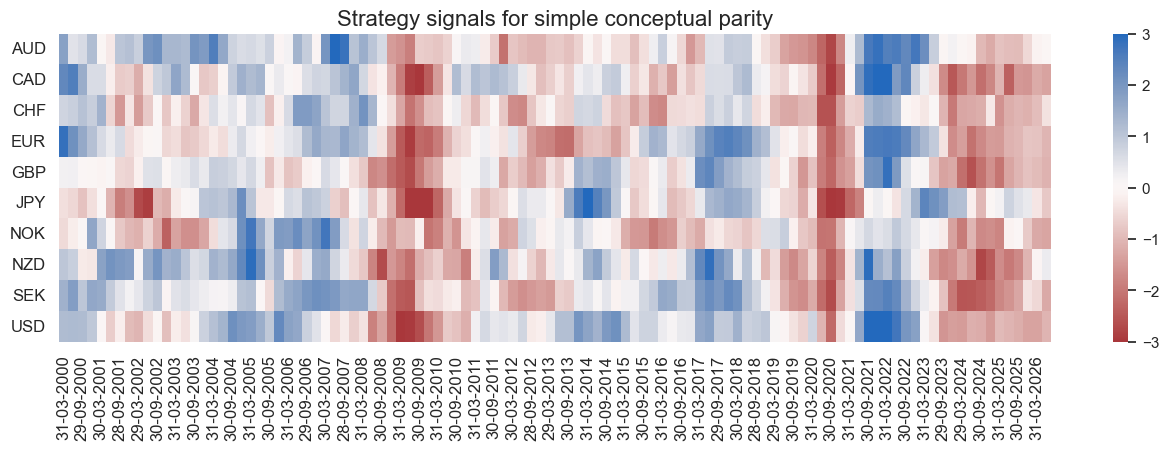

In [82]:
dix = dict_cps

sigx = dix["sigx"]
cidx = dix["cidx"]
start = dix["start"]
naive_pnl = dix["pnls"]

pnl_labels = {
    "CP_PZN": "Simple conceptual parity",
    "BCP_PZN": "Balanced conceptual parity",
    "CPH_PZN": "Hybrid conceptual parity",
    "BCPH_PZN": "Hybrid balanced conceptual parity",
    "Long only": "Passive unit flattening exposure",
}

pnls = [s + "_PZN" for s in sigx] + ["Long only"]

naive_pnl.plot_pnls(
    pnl_cats=pnls,
    pnl_cids=["ALL"],
    start=start,
    title="Macro strategy PnLs for IRS curve positions, 10 developed markets",
    title_fontsize=16,
    figsize=(13, 7),
    xcat_labels=pnl_labels,
)

display(naive_pnl.evaluate_pnls(pnl_cats=pnls))

naive_pnl.signal_heatmap(
    pnl_name=sigx[0] + "_PZN",
    title="Strategy signals for simple conceptual parity",
    title_fontsize=16,
    freq="q",
    start=start,
    figsize=(16, 4),
)

### Naive PnL excluding the GFC

In [83]:
# Conceptual parity PnL ex GFC

naive_pnl = msn.NaivePnL(
    dfx,
    ret=targ,
    sigs=sigx,
    cids=cidx,
    start=start,
    bms=["USD_GB05YXR_NSA", "USD_EQXR_NSA"],
)

for sig in ["CP", "BCP", "CPH", "BCPH"]:
    naive_pnl.make_pnl(
        sig,
        sig_op="zn_score_pan",
        thresh=3,
        rebal_freq="monthly",
        vol_scale=10,
        rebal_slip=1,
        pnl_name=sig + "_PZN",
    )

naive_pnl.make_long_pnl(label="Long only", vol_scale=10)

mask_2008 = naive_pnl.df["real_date"].between("2008-01-01", "2009-12-31")
naive_pnl.df = naive_pnl.df.loc[~mask_2008].copy()

dix["pnlx"] = naive_pnl

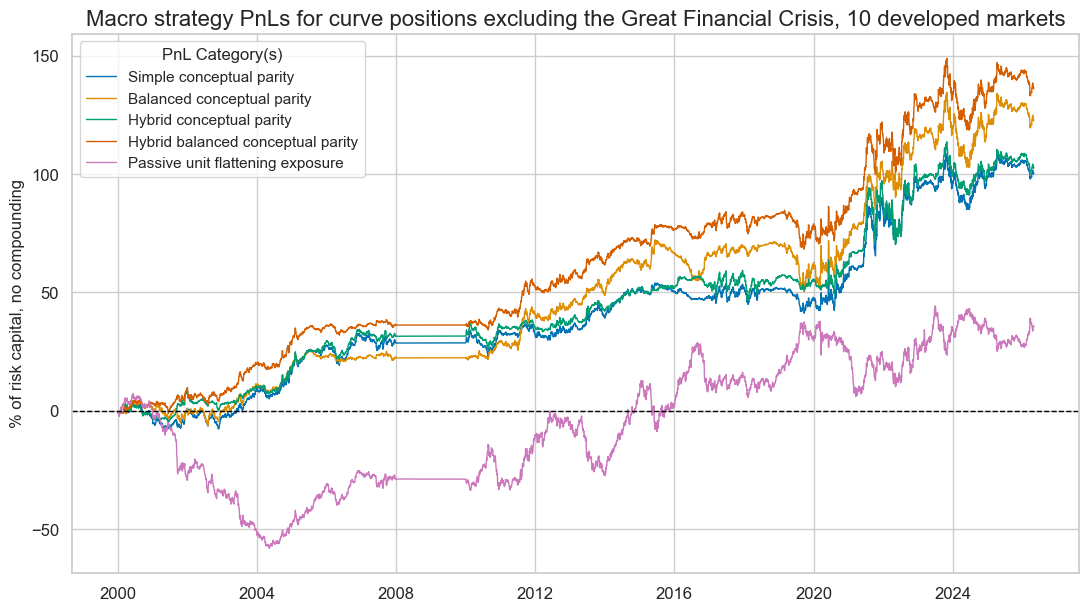

xcat,CP_PZN,BCP_PZN,CPH_PZN,BCPH_PZN,Long only
Return %,4.12647,5.050954,4.228333,5.609911,1.478071
St. Dev. %,8.838236,9.71177,8.64889,9.358726,9.688653
Sharpe Ratio,0.466888,0.520086,0.488887,0.599431,0.152557
Sortino Ratio,0.706139,0.788222,0.733823,0.909739,0.20898
Max 21-Day Draw %,-12.918309,-12.513149,-14.463262,-13.550129,-16.421083
Max 6-Month Draw %,-18.356789,-25.384687,-20.982373,-23.609963,-24.20454
Peak to Trough Draw %,-23.432759,-31.710659,-27.044104,-30.341714,-65.362011
Top 5% Monthly PnL Share,1.209459,1.064669,1.23796,0.96592,3.270513
USD_GB05YXR_NSA correl,-0.008264,-0.029382,0.041843,0.004665,0.30503
USD_EQXR_NSA correl,-0.001203,-0.009758,-0.021828,-0.021632,-0.116398


In [85]:
# Visualization ex GFC

dix = dict_cps

sigx = dix["sigx"]
cidx = dix["cidx"]
start = dix["start"]
naive_pnl = dix["pnlx"]

pnl_labels = {
    "CP_PZN": "Simple conceptual parity",
    "BCP_PZN": "Balanced conceptual parity",
    "CPH_PZN": "Hybrid conceptual parity",
    "BCPH_PZN": "Hybrid balanced conceptual parity",
    "Long only": "Passive unit flattening exposure",
}

pnls = [s + "_PZN" for s in sigx] + ["Long only"]

naive_pnl.plot_pnls(
    pnl_cats=pnls,
    pnl_cids=["ALL"],
    start=start,
    title="Macro strategy PnLs for curve positions excluding the Great Financial Crisis, 10 developed markets",
    title_fontsize=16,
    figsize=(13, 7),
    xcat_labels=pnl_labels,
)

display(naive_pnl.evaluate_pnls(pnl_cats=pnls))